# VizWiz VQA Model Training

Notebook để huấn luyện mô hình Visual Question Answering (VQA) trên dataset VizWiz với dữ liệu đã được tiền xử lý sẵn.

## 1. Import Required Libraries

In [6]:
import os
import sys
import json
import yaml
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
from torch.autograd import Variable
from tqdm import tqdm
from datetime import datetime
import numpy as np
import h5py
from collections import Counter

# Add project path to sys.path
project_path = './VizWiz-VQA-PyTorch-master'
if project_path not in sys.path:
    sys.path.append(project_path)

print("Project path added to sys.path")

# Check if required files exist
print("Checking required files...")
if os.path.exists('./VizWiz-VQA-PyTorch-master/models.py'):
    print("✅ models.py found")
else:
    print("❌ models.py not found")

if os.path.exists('./VizWiz-VQA-PyTorch-master/utils.py'):
    print("✅ utils.py found")
else:
    print("❌ utils.py not found")

if os.path.exists('./VizWiz-VQA-PyTorch-master/datasets/__init__.py'):
    print("✅ datasets/__init__.py found")
else:
    print("❌ datasets/__init__.py not found")

if os.path.exists('./VizWiz-VQA-PyTorch-master/datasets/vqa_dataset.py'):
    print("✅ datasets/vqa_dataset.py found")
else:
    print("❌ datasets/vqa_dataset.py not found")

# Import modules
try:
    import models
    print("✅ models imported")
except ImportError as e:
    print(f"❌ models import failed: {e}")

try:
    import utils
    print("✅ utils imported")
except ImportError as e:
    print(f"❌ utils import failed: {e}")

try:
    from datasets import vqa_dataset
    print("✅ vqa_dataset imported")
except ImportError as e:
    print(f"❌ vqa_dataset import failed: {e}")

print("✅ Import process completed!")

Project path added to sys.path
Checking required files...
✅ models.py found
✅ utils.py found
✅ datasets/__init__.py found
✅ datasets/vqa_dataset.py found
✅ models imported
✅ utils imported
✅ vqa_dataset imported
✅ Import process completed!


## 2. Set Up Paths and Configuration

In [7]:
# Load config từ file YAML
config_path = './VizWiz-VQA-PyTorch-master/config/default.yaml'
with open(config_path, 'r') as handle:
    config = yaml.load(handle, Loader=yaml.FullLoader)

# Cập nhật đường dẫn cho phù hợp với Windows và cấu trúc thư mục thực tế
config['annotations']['dir'] = './data/Annotations'
config['images']['dir'] = './data'
config['annotations']['path_vocabs'] = './prepro_data/vocabs.json'
config['images']['path_features'] = './prepro_data/resnet14x14.h5'  # Sử dụng file mới đã tạo

# Tạo thư mục logs nếu chưa có
log_dir = './logs/vizwiz'
os.makedirs(log_dir, exist_ok=True)

# Thiết lập CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Using device: {device}")

# In ra cấu hình chính
print("📋 Configuration:")
print(f"  - Annotations dir: {config['annotations']['dir']}")
print(f"  - Images dir: {config['images']['dir']}")  
print(f"  - Vocabs path: {config['annotations']['path_vocabs']}")
print(f"  - Features path: {config['images']['path_features']}")
print(f"  - Batch size: {config['training']['batch_size']}")
print(f"  - Learning rate: {config['training']['lr']}")
print(f"  - Epochs: {config['training']['epochs']}")

🔥 Using device: cuda
📋 Configuration:
  - Annotations dir: ./data/Annotations
  - Images dir: ./data
  - Vocabs path: ./prepro_data/vocabs.json
  - Features path: ./prepro_data/resnet14x14.h5
  - Batch size: 128
  - Learning rate: 0.001
  - Epochs: 50


## 3. Verify Pre-processed Data

In [8]:
# Kiểm tra các file cần thiết
required_files = [
    config['annotations']['path_vocabs'],
    config['images']['path_features'],
    config['annotations']['dir'] + '/train.json',
    config['annotations']['dir'] + '/val.json'
]

print("🔍 Checking required files:")
all_files_exist = True
for file_path in required_files:
    if os.path.exists(file_path):
        print(f"  ✅ {file_path}")
        if file_path.endswith('.h5'):
            # Kiểm tra thông tin file .h5
            with h5py.File(file_path, 'r') as f:
                print(f"     - Keys: {list(f.keys())}")
                if 'features' in f:
                    print(f"     - Features shape: {f['features'].shape}")
        elif file_path.endswith('.json') and 'vocabs' in file_path:
            # Kiểm tra vocabs
            with open(file_path, 'r') as f:
                vocabs = json.load(f)
                print(f"     - Question vocab size: {len(vocabs['question'])}")
                print(f"     - Answer vocab size: {len(vocabs['answer'])}")
    else:
        print(f"  ❌ {file_path} - NOT FOUND!")
        all_files_exist = False

if all_files_exist:
    print("\n✅ All required files found! Ready to proceed with training.")
else:
    print("\n❌ Some required files are missing. Please check the paths.")

🔍 Checking required files:
  ✅ ./prepro_data/vocabs.json
     - Question vocab size: 3891
     - Answer vocab size: 3000
  ✅ ./prepro_data/resnet14x14.h5
     - Keys: ['att', 'image', 'noatt']
  ✅ ./data/Annotations/train.json
  ✅ ./data/Annotations/val.json

✅ All required files found! Ready to proceed with training.


## 4. Extract Image Features

In [7]:
# Trích xuất đặc trưng ảnh từ dữ liệu có sẵn
print("🖼️ Starting image feature extraction...")

# Import các module cần thiết cho feature extraction
import torchvision.models as models
from datasets.images import get_transform
import time
from PIL import Image

class MultiDirImageDataset(torch.utils.data.Dataset):
    """Dataset để load ảnh từ nhiều thư mục con"""
    
    def __init__(self, base_dir, subdirs=['train', 'val', 'test'], transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.image_paths = []
        self.image_names = []
        
        # Load tất cả ảnh từ các thư mục con
        IMG_EXTENSIONS = ['.jpg', '.JPG', '.jpeg', '.JPEG', '.png', '.PNG', '.ppm', '.PPM', '.bmp', '.BMP']
        
        for subdir in subdirs:
            subdir_path = os.path.join(base_dir, subdir)
            if os.path.exists(subdir_path):
                print(f"📂 Scanning {subdir_path}...")
                for filename in os.listdir(subdir_path):
                    if any(filename.endswith(ext) for ext in IMG_EXTENSIONS):
                        full_path = os.path.join(subdir_path, filename)
                        self.image_paths.append(full_path)
                        self.image_names.append(filename)
        
        print(f"📊 Found {len(self.image_paths)} images total")
        
        if len(self.image_paths) == 0:
            raise RuntimeError(f"Found 0 images in {base_dir}")
    
    def __getitem__(self, index):
        item = {}
        item['name'] = self.image_names[index]
        item['path'] = self.image_paths[index]
        
        # Load ảnh bằng PIL
        try:
            item['visual'] = Image.open(item['path']).convert('RGB')
            if self.transform is not None:
                item['visual'] = self.transform(item['visual'])
        except Exception as e:
            print(f"❌ Error loading image {item['path']}: {e}")
            # Tạo ảnh trắng thay thế
            item['visual'] = Image.new('RGB', (224, 224), (255, 255, 255))
            if self.transform is not None:
                item['visual'] = self.transform(item['visual'])
        
        return item
    
    def __len__(self):
        return len(self.image_paths)

class NetFeatureExtractor(nn.Module):
    """Feature extractor sử dụng ResNet152"""
    
    def __init__(self):
        super(NetFeatureExtractor, self).__init__()
        self.model = models.resnet152(weights='IMAGENET1K_V1')  # Updated for newer PyTorch
        # Sử dụng AdaptiveAvgPool2d để cho phép input size lớn hơn
        self.model.avgpool = nn.AdaptiveAvgPool2d(1)

        # Hook để lưu attention features (tensor)
        def save_att_features(module, input, output):
            self.att_feat = output

        # Hook để lưu no-attention features (vector) 
        def save_noatt_features(module, input, output):
            self.no_att_feat = output

        # Đăng ký forward hooks
        self.model.layer4.register_forward_hook(save_att_features)
        self.model.avgpool.register_forward_hook(save_noatt_features)

    def forward(self, x):
        self.model(x)
        return self.no_att_feat, self.att_feat  # [batch_size, 2048], [batch_size, 2048, 14, 14]

# Đường dẫn file features mới
feature_file_path = './prepro_data/resnet14x14.h5'

print("🚀 Starting feature extraction...")

# Thiết lập CUDA benchmark
torch.backends.cudnn.benchmark = True

# Khởi tạo feature extractor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = NetFeatureExtractor().to(device)
net.eval()

# Thiết lập data loader cho ảnh
transform = get_transform(config['images']['img_size'])
dataset = MultiDirImageDataset(config['images']['dir'], transform=transform)

data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=config['images']['preprocess_batch_size'],
    num_workers=0,  # Set to 0 for Windows compatibility
    shuffle=False,
    pin_memory=True,
)

print(f"📊 Processing {len(dataset)} images in {len(data_loader)} batches")

# Tạo file HDF5 để lưu features
h5_file = h5py.File(feature_file_path, 'w')

# Tạo dummy input để xác định kích thước output
dummy_input = Variable(torch.ones(1, 3, config['images']['img_size'], config['images']['img_size'])).to(device)
with torch.no_grad():
    _, dummy_output = net(dummy_input)

# Định nghĩa kích thước datasets
att_features_shape = (
    len(dataset),
    dummy_output.size(1),  # 2048
    dummy_output.size(2),  # 14
    dummy_output.size(3)   # 14
)

noatt_features_shape = (
    len(dataset),
    dummy_output.size(1)  # 2048
)

# Tạo HDF5 datasets với key names chính xác
h5_att = h5_file.create_dataset('att', shape=att_features_shape, dtype='float16')
h5_noatt = h5_file.create_dataset('noatt', shape=noatt_features_shape, dtype='float16')

# Lưu tên ảnh với key 'image' (thay vì 'img_name')
dt = h5py.special_dtype(vlen=str)
h5_images = h5_file.create_dataset('image', shape=(len(dataset),), dtype=dt)

print(f"💾 Created HDF5 file with shapes:")
print(f"  - att features: {att_features_shape}")
print(f"  - noatt features: {noatt_features_shape}")
print(f"  - image names: {len(dataset)} entries")

# Trích xuất features
begin = time.time()
idx = 0

for i, inputs in enumerate(tqdm(data_loader, desc="Extracting features")):
    with torch.no_grad():
        inputs_img = Variable(inputs['visual'].to(device, non_blocking=True))
        no_att_feat, att_feat = net(inputs_img)
        
        # Reshape no attention features
        no_att_feat = no_att_feat.view(-1, 2048)
        
        # Lưu vào HDF5
        batch_size = inputs_img.size(0)
        h5_noatt[idx:idx + batch_size] = no_att_feat.data.cpu().numpy().astype('float16')
        h5_att[idx:idx + batch_size, :, :] = att_feat.data.cpu().numpy().astype('float16')
        h5_images[idx:idx + batch_size] = inputs['name']  # Lưu vào key 'image'
        
        idx += batch_size

h5_file.close()

end = time.time() - begin
print(f'✅ Feature extraction completed in {int(end / 60)}m {int(end % 60)}s')
print(f'💾 Created file: {feature_file_path}')

# Kiểm tra lại file vừa tạo
print(f"\n🔍 Verifying created file:")
with h5py.File(feature_file_path, 'r') as f:
    print(f"📊 HDF5 file structure:")
    for key in f.keys():
        if key == 'image':
            print(f"  - {key}: {len(f[key])} image names")
            # Hiển thị một vài tên ảnh mẫu
            sample_names = f[key][:3]
            print(f"    Sample names: {[name.decode('utf-8') if isinstance(name, bytes) else name for name in sample_names]}")
        else:
            print(f"  - {key}: shape {f[key].shape}, dtype {f[key].dtype}")

# Cập nhật config để sử dụng file features mới
config['images']['path_features'] = feature_file_path
print(f"🔧 Updated config to use: {config['images']['path_features']}")

🖼️ Starting image feature extraction...
🚀 Starting feature extraction...
📂 Scanning ./data\train...
📂 Scanning ./data\val...
📂 Scanning ./data\test...
📊 Found 28273 images total
📊 Processing 28273 images in 7069 batches
📂 Scanning ./data\train...
📂 Scanning ./data\val...
📂 Scanning ./data\test...
📊 Found 28273 images total
📊 Processing 28273 images in 7069 batches
💾 Created HDF5 file with shapes:
  - att features: (28273, 2048, 14, 14)
  - noatt features: (28273, 2048)
  - image names: 28273 entries
💾 Created HDF5 file with shapes:
  - att features: (28273, 2048, 14, 14)
  - noatt features: (28273, 2048)
  - image names: 28273 entries


Extracting features: 100%|██████████| 7069/7069 [1:04:24<00:00,  1.83it/s]

✅ Feature extraction completed in 64m 24s
💾 Created file: ./prepro_data/resnet14x14.h5

🔍 Verifying created file:
📊 HDF5 file structure:
  - att: shape (28273, 2048, 14, 14), dtype float16
  - image: 28273 image names
    Sample names: ['VizWiz_train_00002052.jpg', 'VizWiz_train_00002053.jpg', 'VizWiz_train_00002054.jpg']
  - noatt: shape (28273, 2048), dtype float16
🔧 Updated config to use: ./prepro_data/resnet14x14.h5


## 5. Create Data Loaders

In [15]:
# Create data loaders for training and validation
print("📊 Creating data loaders...")

# Load datasets - VQADataset only takes config and split parameters
train_dataset = vqa_dataset.VQADataset(config, 'train')
val_dataset = vqa_dataset.VQADataset(config, 'val')

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=config['training']['batch_size'],
    num_workers=0,  # Set to 0 for Windows compatibility
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
    collate_fn=vqa_dataset.collate_fn  # Use the collate_fn from the dataset module
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=config['training']['batch_size'],
    num_workers=0,  # Set to 0 for Windows compatibility
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
    collate_fn=vqa_dataset.collate_fn  # Use the collate_fn from the dataset module
)

print(f"✅ Data loaders created successfully!")
print(f"📈 Training dataset:")
print(f"  - Samples: {len(train_dataset):,}")
print(f"  - Batches: {len(train_loader):,}")
print(f"  - Vocabulary size (questions): {len(train_dataset.vocabs['question']):,}")
print(f"  - Vocabulary size (answers): {len(train_dataset.vocabs['answer']):,}")

print(f"📊 Validation dataset:")
print(f"  - Samples: {len(val_dataset):,}")
print(f"  - Batches: {len(val_loader):,}")

# Check vocabulary consistency
assert train_dataset.num_tokens == val_dataset.num_tokens, "Token counts don't match between train and val datasets"
print(f"🔢 Total vocabulary tokens: {train_dataset.num_tokens:,}")

# Test loading a batch to ensure everything works
print("\n🧪 Testing data loader...")
try:
    sample_batch = next(iter(train_loader))
    print(f"✅ Sample batch loaded successfully!")
    print(f"  - Visual features shape: {sample_batch['visual'].shape}")
    print(f"  - Question shape: {sample_batch['question'].shape}")
    print(f"  - Answer shape: {sample_batch['answer'].shape}")
    print(f"  - Question length shape: {sample_batch['q_length'].shape}")
except Exception as e:
    print(f"❌ Error loading sample batch: {e}")
    raise

📊 Creating data loaders...
✅ Data loaders created successfully!
📈 Training dataset:
  - Samples: 17,917
  - Batches: 139
  - Vocabulary size (questions): 3,891
  - Vocabulary size (answers): 3,000
📊 Validation dataset:
  - Samples: 2,052
  - Batches: 17
🔢 Total vocabulary tokens: 3,892

🧪 Testing data loader...
✅ Data loaders created successfully!
📈 Training dataset:
  - Samples: 17,917
  - Batches: 139
  - Vocabulary size (questions): 3,891
  - Vocabulary size (answers): 3,000
📊 Validation dataset:
  - Samples: 2,052
  - Batches: 17
🔢 Total vocabulary tokens: 3,892

🧪 Testing data loader...
✅ Sample batch loaded successfully!
  - Visual features shape: torch.Size([128, 2048, 14, 14])
  - Question shape: torch.Size([128, 26])
  - Answer shape: torch.Size([128, 3000])
  - Question length shape: torch.Size([128])
✅ Sample batch loaded successfully!
  - Visual features shape: torch.Size([128, 2048, 14, 14])
  - Question shape: torch.Size([128, 26])
  - Answer shape: torch.Size([128, 3000]

## 6. Initialize Model Architecture

In [16]:
# Initialize model
print("🤖 Initializing VQA model...")
model = models.Model(config, train_loader.dataset.num_tokens)

# Move model to GPU if available
if torch.cuda.is_available():
    model = nn.DataParallel(model).cuda()
    print(f"✅ Model moved to GPU with {torch.cuda.device_count()} device(s)")
else:
    print("⚠️ GPU not available, using CPU")

# Print model architecture overview
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📐 Model Architecture:")
print(f"  - Total parameters: {total_params:,}")
print(f"  - Trainable parameters: {trainable_params:,}")
print(f"  - Model components:")
print(f"    * Text encoder: {config['model']['seq2vec']}")
print(f"    * Attention: {config['model']['attention']}")
print(f"    * Classifier: {config['model']['classifier']}")

# Load pretrained model if specified
if config['model']['pretrained_model'] is not None and os.path.exists(config['model']['pretrained_model']):
    print(f"📥 Loading pretrained model from {config['model']['pretrained_model']}")
    checkpoint = torch.load(config['model']['pretrained_model'])
    model.load_state_dict(checkpoint['weights'])
    print("✅ Pretrained model loaded successfully!")
else:
    print("🆕 Training from scratch (no pretrained model)")

🤖 Initializing VQA model...
✅ Model moved to GPU with 1 device(s)

📐 Model Architecture:
  - Total parameters: 16,492,202
  - Trainable parameters: 16,492,202
  - Model components:
    * Text encoder: {'dropout': 0.25, 'emb_size': 300}
    * Attention: {'glimpses': 2, 'mid_features': 512, 'dropout': 0.5}
    * Classifier: {'dropout': 0.5}
🆕 Training from scratch (no pretrained model)
✅ Model moved to GPU with 1 device(s)

📐 Model Architecture:
  - Total parameters: 16,492,202
  - Trainable parameters: 16,492,202
  - Model components:
    * Text encoder: {'dropout': 0.25, 'emb_size': 300}
    * Attention: {'glimpses': 2, 'mid_features': 512, 'dropout': 0.5}
    * Classifier: {'dropout': 0.5}
🆕 Training from scratch (no pretrained model)


## 7. Configure Training Parameters

In [17]:
# Setup optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config['training']['lr']
)

# Setup tracking
tracker = utils.Tracker()

# Training parameters
num_epochs = config['training']['epochs']
batch_size = config['training']['batch_size']
learning_rate = config['training']['lr']

print("⚙️ Training Configuration:")
print(f"  - Optimizer: Adam")
print(f"  - Learning rate: {learning_rate}")
print(f"  - Batch size: {batch_size}")
print(f"  - Number of epochs: {num_epochs}")
print(f"  - Total training batches per epoch: {len(train_loader)}")
print(f"  - Total validation batches: {len(val_loader)}")

# Create log directory with timestamp
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_dir_timestamped = os.path.join(log_dir, timestamp)
os.makedirs(log_dir_timestamped, exist_ok=True)

print(f"📁 Logs will be saved to: {log_dir_timestamped}")

# Paths for saving best models
best_accuracy_path = os.path.join(log_dir_timestamped, 'best_accuracy_model.pth')
best_loss_path = os.path.join(log_dir_timestamped, 'best_loss_model.pth')
final_model_path = os.path.join(log_dir_timestamped, 'final_model.pth')

print(f"💾 Model checkpoints:")
print(f"  - Best accuracy: {best_accuracy_path}")
print(f"  - Best loss: {best_loss_path}")
print(f"  - Final model: {final_model_path}")

⚙️ Training Configuration:
  - Optimizer: Adam
  - Learning rate: 0.001
  - Batch size: 128
  - Number of epochs: 50
  - Total training batches per epoch: 139
  - Total validation batches: 17
📁 Logs will be saved to: ./logs/vizwiz\2025-08-03_08-06-27
💾 Model checkpoints:
  - Best accuracy: ./logs/vizwiz\2025-08-03_08-06-27\best_accuracy_model.pth
  - Best loss: ./logs/vizwiz\2025-08-03_08-06-27\best_loss_model.pth
  - Final model: ./logs/vizwiz\2025-08-03_08-06-27\final_model.pth


## 8. Train the Model

In [18]:
# Training functions
def train_epoch(model, loader, optimizer, tracker, epoch):
    """Train model for one epoch"""
    model.train()
    
    tracker_class, tracker_params = tracker.MovingMeanMonitor, {'momentum': 0.99}
    tq = tqdm(loader, desc='Train E{:03d}'.format(epoch), ncols=0)
    loss_tracker = tracker.track('train_loss', tracker_class(**tracker_params))
    acc_tracker = tracker.track('train_acc', tracker_class(**tracker_params))
    log_softmax = nn.LogSoftmax(dim=1).cuda() if torch.cuda.is_available() else nn.LogSoftmax(dim=1)

    for item in tq:
        v = item['visual']
        q = item['question']
        a = item['answer']
        q_length = item['q_length']

        # Move to GPU if available
        if torch.cuda.is_available():
            v = Variable(v.cuda(non_blocking=True))
            q = Variable(q.cuda(non_blocking=True))
            a = Variable(a.cuda(non_blocking=True))
            q_length = Variable(q_length.cuda(non_blocking=True))
        else:
            v = Variable(v)
            q = Variable(q)
            a = Variable(a)
            q_length = Variable(q_length)

        # Forward pass
        out = model(v, q, q_length)

        # Calculate loss (Soft-loss from VQA paper)
        nll = -log_softmax(out)
        loss = (nll * a / 10).sum(dim=1).mean()
        
        # Calculate accuracy
        acc = utils.vqa_accuracy(out.data, a.data).cpu()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update trackers
        loss_tracker.append(loss.item())
        acc_tracker.append(acc.mean())
        
        # Update progress bar
        fmt = '{:.4f}'.format
        tq.set_postfix(loss=fmt(loss_tracker.mean.value), acc=fmt(acc_tracker.mean.value))
    
    return loss_tracker.mean.value, acc_tracker.mean.value


def evaluate_epoch(model, loader, tracker, epoch):
    """Evaluate model for one epoch"""
    model.eval()
    
    tracker_class, tracker_params = tracker.MeanMonitor, {}
    tq = tqdm(loader, desc='Val E{:03d}'.format(epoch), ncols=0)
    loss_tracker = tracker.track('val_loss', tracker_class(**tracker_params))
    acc_tracker = tracker.track('val_acc', tracker_class(**tracker_params))
    log_softmax = nn.LogSoftmax(dim=1).cuda() if torch.cuda.is_available() else nn.LogSoftmax(dim=1)

    predictions = []
    samples_ids = []
    accuracies = []

    with torch.no_grad():
        for item in tq:
            v = item['visual']
            q = item['question']
            a = item['answer']
            sample_id = item['sample_id']
            q_length = item['q_length']

            # Move to GPU if available
            if torch.cuda.is_available():
                v = Variable(v.cuda(non_blocking=True))
                q = Variable(q.cuda(non_blocking=True))
                a = Variable(a.cuda(non_blocking=True))
                q_length = Variable(q_length.cuda(non_blocking=True))
            else:
                v = Variable(v)
                q = Variable(q)
                a = Variable(a)
                q_length = Variable(q_length)

            # Forward pass
            out = model(v, q, q_length)

            # Calculate loss
            nll = -log_softmax(out)
            loss = (nll * a / 10).sum(dim=1).mean()
            
            # Calculate accuracy
            acc = utils.vqa_accuracy(out.data, a.data).cpu()

            # Save predictions
            _, answer = out.data.cpu().max(dim=1)
            predictions.append(answer.view(-1))
            accuracies.append(acc.view(-1))
            samples_ids.append(sample_id.view(-1).clone())

            # Update trackers
            loss_tracker.append(loss.item())
            acc_tracker.append(acc.mean())
            
            # Update progress bar
            fmt = '{:.4f}'.format
            tq.set_postfix(loss=fmt(loss_tracker.mean.value), acc=fmt(acc_tracker.mean.value))

    # Combine predictions
    predictions = list(torch.cat(predictions, dim=0))
    accuracies = list(torch.cat(accuracies, dim=0))
    samples_ids = list(torch.cat(samples_ids, dim=0))

    eval_results = {
        'answers': predictions,
        'accuracies': accuracies,
        'samples_ids': samples_ids,
        'avg_accuracy': acc_tracker.mean.value,
        'avg_loss': loss_tracker.mean.value
    }

    return eval_results

print("✅ Training functions defined successfully!")

✅ Training functions defined successfully!


In [19]:
# Main training loop
print("🚀 Starting training...")

best_val_accuracy = 0.0
best_val_loss = float('inf')

# Training history for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\n📍 Epoch {epoch + 1}/{num_epochs}")
    
    # Training phase
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, tracker, epoch)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Validation phase
    eval_results = evaluate_epoch(model, val_loader, tracker, epoch)
    val_loss = eval_results['avg_loss']
    val_acc = eval_results['avg_accuracy']
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # Print epoch summary
    print(f"  📊 Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
    print(f"  📊 Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    # Save model checkpoints
    log_data = {
        'epoch': epoch,
        'tracker': tracker.to_dict(),
        'config': config,
        'weights': model.state_dict(),
        'eval_results': eval_results,
        'vocabs': train_loader.dataset.vocabs,
        'train_history': {
            'train_losses': train_losses,
            'train_accuracies': train_accuracies,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies
        }
    }
    
    # Save best accuracy model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(log_data, best_accuracy_path)
        print(f"  💾 New best accuracy: {best_val_accuracy:.4f} - Model saved!")
    
    # Save best loss model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(log_data, best_loss_path)
        print(f"  💾 New best loss: {best_val_loss:.4f} - Model saved!")

# Save final model
final_log_data = {
    'tracker': tracker.to_dict(),
    'config': config,
    'weights': model.state_dict(),
    'vocabs': train_loader.dataset.vocabs,
    'train_history': {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }
}
torch.save(final_log_data, final_model_path)

print(f"\n🎉 Training completed!")
print(f"  📈 Best validation accuracy: {best_val_accuracy:.4f}")
print(f"  📉 Best validation loss: {best_val_loss:.4f}")
print(f"  💾 Models saved to: {log_dir_timestamped}")

🚀 Starting training...

📍 Epoch 1/50


Train E000: 100% 139/139 [01:40<00:00,  1.39it/s, acc=0.3720, loss=4.1317]
Train E000: 100% 139/139 [01:40<00:00,  1.39it/s, acc=0.3720, loss=4.1317]
Val E000: 100% 17/17 [00:08<00:00,  2.03it/s, acc=0.4796, loss=3.3295]



  📊 Train - Loss: 4.1317, Acc: 0.3720
  📊 Val   - Loss: 3.3295, Acc: 0.4796
  💾 New best accuracy: 0.4796 - Model saved!
  💾 New best accuracy: 0.4796 - Model saved!
  💾 New best loss: 3.3295 - Model saved!

📍 Epoch 2/50
  💾 New best loss: 3.3295 - Model saved!

📍 Epoch 2/50


Train E001: 100% 139/139 [01:40<00:00,  1.39it/s, acc=0.5151, loss=3.2252]
Train E001: 100% 139/139 [01:40<00:00,  1.39it/s, acc=0.5151, loss=3.2252]
Val E001: 100% 17/17 [00:08<00:00,  2.10it/s, acc=0.4914, loss=3.1667]



  📊 Train - Loss: 3.2252, Acc: 0.5151
  📊 Val   - Loss: 3.1667, Acc: 0.4914
  💾 New best accuracy: 0.4914 - Model saved!
  💾 New best accuracy: 0.4914 - Model saved!
  💾 New best loss: 3.1667 - Model saved!

📍 Epoch 3/50
  💾 New best loss: 3.1667 - Model saved!

📍 Epoch 3/50


...

  📊 Train - Loss: 0.8905, Acc: 0.8330
  📊 Val   - Loss: 2.9284, Acc: 0.5512

📍 Epoch 49/50


Train E048: 100% 139/139 [01:48<00:00,  1.28it/s, acc=0.8223, loss=0.8871]
Train E048: 100% 139/139 [01:48<00:00,  1.28it/s, acc=0.8223, loss=0.8871]
Val E048: 100% 17/17 [00:08<00:00,  2.04it/s, acc=0.5524, loss=2.9124]



  📊 Train - Loss: 0.8871, Acc: 0.8223
  📊 Val   - Loss: 2.9124, Acc: 0.5524

📍 Epoch 50/50


Train E049: 100% 139/139 [01:45<00:00,  1.32it/s, acc=0.8224, loss=0.8940]
Train E049: 100% 139/139 [01:45<00:00,  1.32it/s, acc=0.8224, loss=0.8940]
Val E049: 100% 17/17 [00:08<00:00,  1.99it/s, acc=0.5518, loss=2.8781]



  📊 Train - Loss: 0.8940, Acc: 0.8224
  📊 Val   - Loss: 2.8781, Acc: 0.5518

🎉 Training completed!
  📈 Best validation accuracy: 0.5593
  📉 Best validation loss: 2.5748
  💾 Models saved to: ./logs/vizwiz\2025-08-03_08-06-27

🎉 Training completed!
  📈 Best validation accuracy: 0.5593
  📉 Best validation loss: 2.5748
  💾 Models saved to: ./logs/vizwiz\2025-08-03_08-06-27


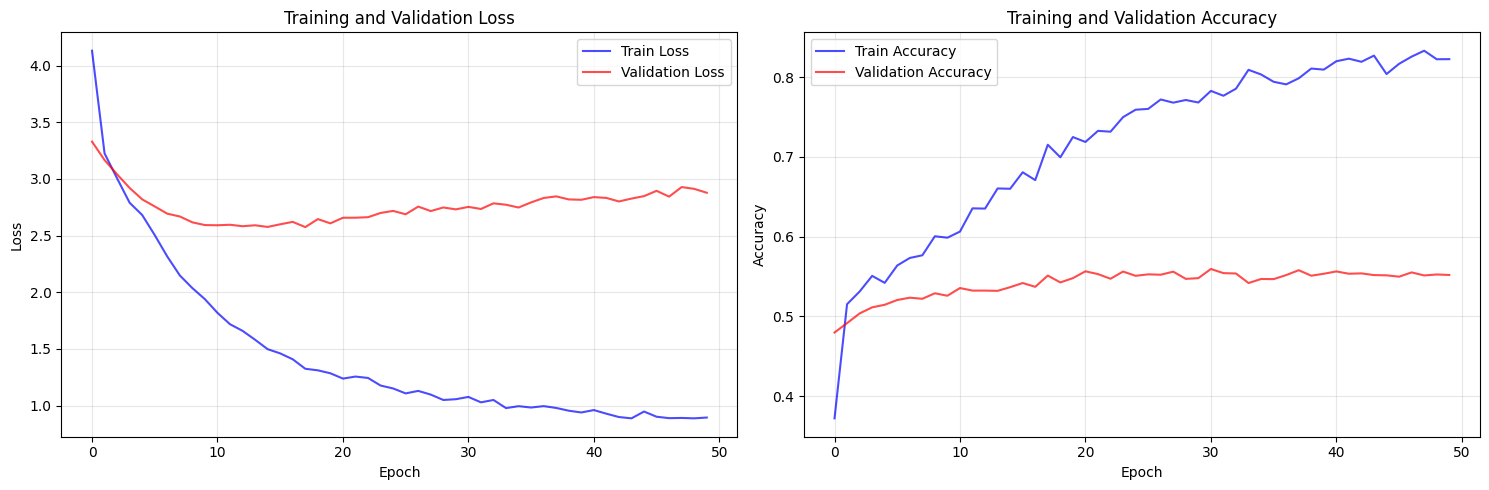

📊 Training history plotted and saved!


In [20]:
# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(train_losses, label='Train Loss', color='blue', alpha=0.7)
ax1.plot(val_losses, label='Validation Loss', color='red', alpha=0.7)
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(train_accuracies, label='Train Accuracy', color='blue', alpha=0.7)
ax2.plot(val_accuracies, label='Validation Accuracy', color='red', alpha=0.7)
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(log_dir_timestamped, 'training_history.png'), dpi=300, bbox_inches='tight')
plt.show()

print("📊 Training history plotted and saved!")

## 9. Load Trained Model for Prediction

In [21]:
# Load the best trained model for inference
print("📥 Loading best trained model...")

# You can choose which model to load:
# - best_accuracy_path: Model with highest validation accuracy
# - best_loss_path: Model with lowest validation loss
# - final_model_path: Final model after all epochs

model_path = best_accuracy_path  # Change this to load different checkpoint

if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=device)
    
    # Load model weights
    model.load_state_dict(checkpoint['weights'])
    model.eval()
    
    # Load vocabularies for answer decoding
    loaded_vocabs = checkpoint['vocabs']
    
    # Create index to answer mapping
    idx_to_answer = {v: k for k, v in loaded_vocabs['answer'].items()}
    
    print(f"✅ Model loaded successfully from: {model_path}")
    print(f"📊 Model performance:")
    if 'eval_results' in checkpoint:
        eval_results = checkpoint['eval_results']
        print(f"  - Validation accuracy: {eval_results['avg_accuracy']:.4f}")
        print(f"  - Validation loss: {eval_results['avg_loss']:.4f}")
    
    print(f"📖 Vocabulary loaded: {len(loaded_vocabs['answer'])} answers")
    
else:
    print(f"❌ Model file not found: {model_path}")
    print("🔄 Please run the training section first!")

📥 Loading best trained model...
✅ Model loaded successfully from: ./logs/vizwiz\2025-08-03_08-06-27\best_accuracy_model.pth
📊 Model performance:
  - Validation accuracy: 0.5593
  - Validation loss: 2.7534
📖 Vocabulary loaded: 3000 answers
✅ Model loaded successfully from: ./logs/vizwiz\2025-08-03_08-06-27\best_accuracy_model.pth
📊 Model performance:
  - Validation accuracy: 0.5593
  - Validation loss: 2.7534
📖 Vocabulary loaded: 3000 answers


## 10. Generate Predictions on Validation Set

In [22]:
# Generate predictions on validation set
print("🔮 Generating predictions on validation set...")

model.eval()
predictions = []

# Create predictions directory
pred_dir = './predictions'
os.makedirs(pred_dir, exist_ok=True)

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_loader, desc="Generating predictions")):
        v = batch['visual']
        q = batch['question']
        q_length = batch['q_length']
        img_names = batch['img_name']
        
        # Move to GPU if available
        if torch.cuda.is_available():
            v = Variable(v.cuda(non_blocking=True))
            q = Variable(q.cuda(non_blocking=True))
            q_length = Variable(q_length.cuda(non_blocking=True))
        else:
            v = Variable(v)
            q = Variable(q)
            q_length = Variable(q_length)
        
        # Forward pass
        output = model(v, q, q_length)
        
        # Get predicted answer indices
        _, predicted_indices = output.data.cpu().max(dim=1)
        
        # Convert predictions to answers
        for i, pred_idx in enumerate(predicted_indices):
            pred_answer = idx_to_answer.get(pred_idx.item(), '<unknown>')
            img_name = img_names[i]
            
            # Handle byte strings
            if isinstance(img_name, bytes):
                img_name = img_name.decode('utf-8')
            
            predictions.append({
                'image': img_name,
                'answer': pred_answer
            })

# Save predictions to JSON file
pred_file = os.path.join(pred_dir, 'validation_predictions.json')
with open(pred_file, 'w') as f:
    json.dump(predictions, f, indent=2)

print(f"✅ Generated {len(predictions)} predictions")
print(f"💾 Predictions saved to: {pred_file}")

# Show some sample predictions
print("\n🔍 Sample predictions:")
for i in range(min(5, len(predictions))):
    pred = predictions[i]
    print(f"  Image: {pred['image']}")
    print(f"  Predicted answer: {pred['answer']}")
    print()

🔮 Generating predictions on validation set...


Generating predictions: 100%|██████████| 17/17 [00:07<00:00,  2.15it/s]

✅ Generated 2052 predictions
💾 Predictions saved to: ./predictions\validation_predictions.json

🔍 Sample predictions:
  Image: VizWiz_train_00000107.jpg
  Predicted answer: unanswerable

  Image: VizWiz_train_00000033.jpg
  Predicted answer: unanswerable

  Image: VizWiz_train_00000109.jpg
  Predicted answer: unanswerable

  Image: VizWiz_train_00000024.jpg
  Predicted answer: unanswerable

  Image: VizWiz_train_00000075.jpg
  Predicted answer: unanswerable



## 11. Evaluate Model Performance

📊 Evaluating model performance...
🎯 Overall Accuracy: 0.5770 (1184.0/2052)

📈 Accuracy by Answer Type:
  yes/no      : 0.6489 (  94 samples,   4.6%)
  number      : 0.1458 (  32 samples,   1.6%)
  unanswerable: 0.9143 ( 766 samples,  37.3%)
  other       : 0.3603 (1160 samples,  56.5%)


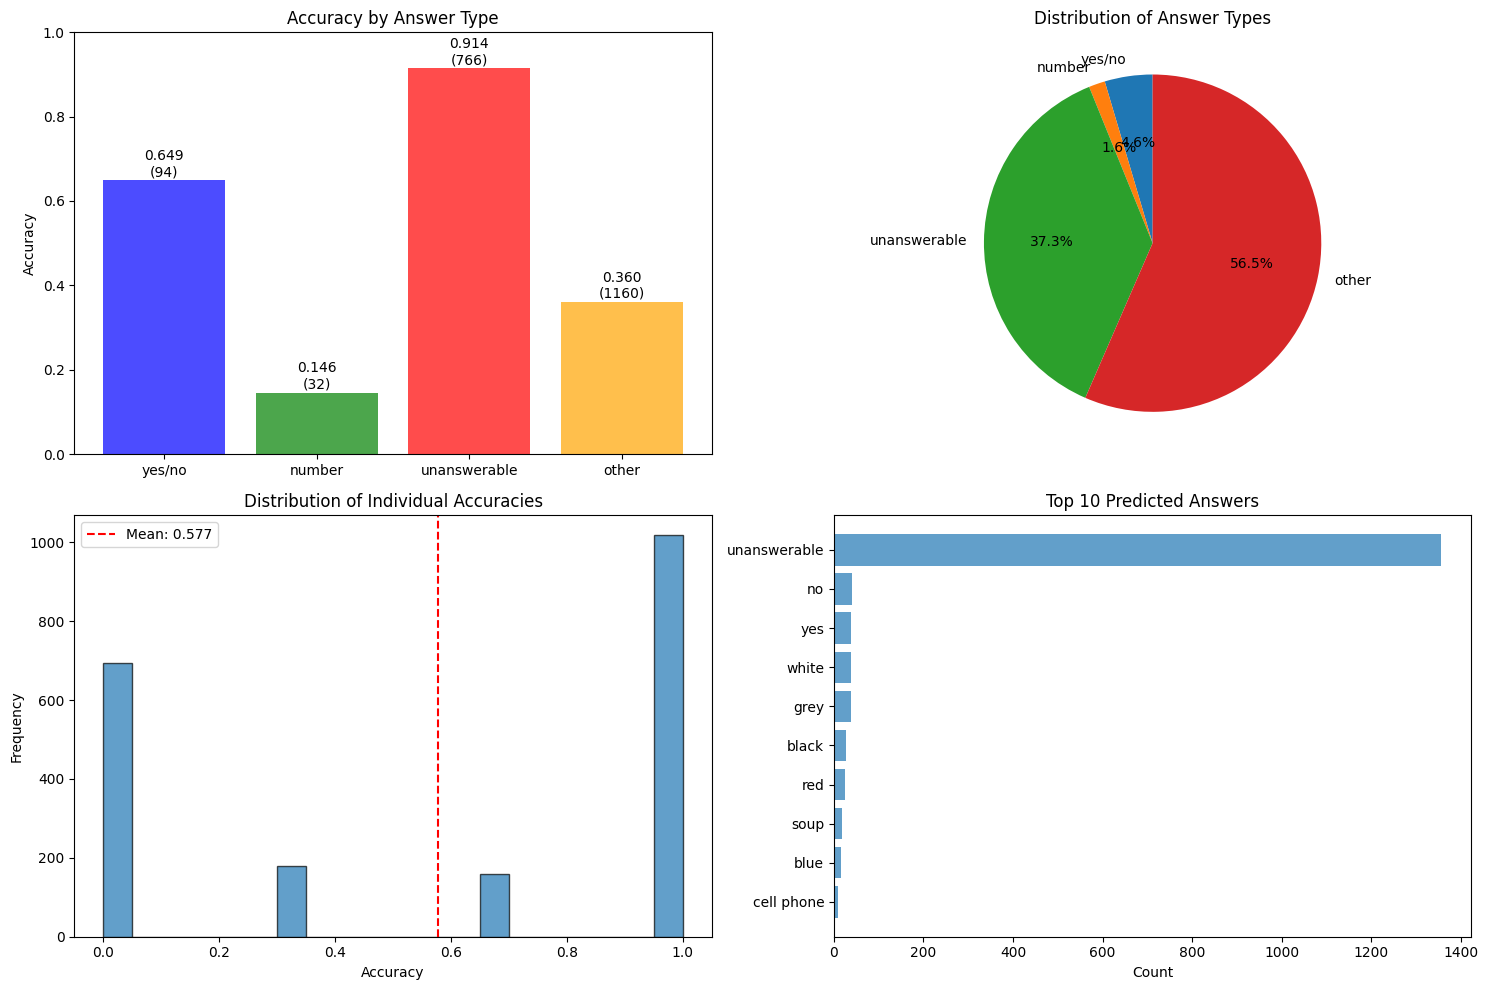


💾 Detailed evaluation results saved to: ./logs/vizwiz\2025-08-03_08-06-27\evaluation_summary.json
📊 Evaluation plots saved to: ./logs/vizwiz\2025-08-03_08-06-27

🎉 Evaluation completed!
🎯 Final Model Performance: 0.5770 accuracy on validation set


In [23]:
# Load validation annotations for evaluation
val_annotations_path = os.path.join(config['annotations']['dir'], 'val.json')
with open(val_annotations_path, 'r') as f:
    val_annotations = json.load(f)

# Create mapping from image to ground truth answers
img_to_gt = {annotation['image']: annotation['answers'] for annotation in val_annotations}

print("📊 Evaluating model performance...")

# Calculate accuracy for each prediction
img_to_accuracy = {}
total_correct = 0
total_samples = 0

for pred in predictions:
    img_name = pred['image']
    pred_answer = pred['answer'].lower()
    
    if img_name in img_to_gt:
        gt_answers = img_to_gt[img_name]
        gt_answer_texts = [ans['answer'].lower() for ans in gt_answers]
        
        # VQA accuracy: min(1.0, count(pred_answer in GT) / 3.0)
        count = gt_answer_texts.count(pred_answer)
        accuracy = min(1.0, count / 3.0)
        
        img_to_accuracy[img_name] = accuracy
        total_correct += accuracy
        total_samples += 1

# Overall accuracy
overall_accuracy = total_correct / total_samples if total_samples > 0 else 0

print(f"🎯 Overall Accuracy: {overall_accuracy:.4f} ({total_correct:.1f}/{total_samples})")

# Categorize answers by type for detailed analysis
answer_type_mapping = {}
answer_type_accuracies = {
    'yes/no': [],
    'number': [],
    'unanswerable': [],
    'other': []
}

for annotation in val_annotations:
    img_name = annotation['image']
    answers = annotation['answers']
    
    # Find most common answer
    answer_counts = Counter([ans['answer'].lower() for ans in answers])
    most_common_answer = answer_counts.most_common(1)[0][0]
    
    # Categorize answer type
    if most_common_answer in ['yes', 'no']:
        answer_type = 'yes/no'
    elif most_common_answer in ['unanswerable', 'unsuitable']:
        answer_type = 'unanswerable'
    elif most_common_answer.isdigit():
        answer_type = 'number'
    else:
        answer_type = 'other'
    
    answer_type_mapping[img_name] = answer_type
    
    # Add accuracy to corresponding category
    if img_name in img_to_accuracy:
        answer_type_accuracies[answer_type].append(img_to_accuracy[img_name])

# Calculate accuracy by answer type
print("\n📈 Accuracy by Answer Type:")
answer_type_stats = {}
for answer_type, accuracies in answer_type_accuracies.items():
    if accuracies:
        avg_accuracy = np.mean(accuracies)
        count = len(accuracies)
        percentage = count / total_samples * 100
        answer_type_stats[answer_type] = {
            'accuracy': avg_accuracy,
            'count': count,
            'percentage': percentage
        }
        print(f"  {answer_type:12s}: {avg_accuracy:.4f} ({count:4d} samples, {percentage:5.1f}%)")
    else:
        print(f"  {answer_type:12s}: No samples")

# Create visualization of results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy by answer type
types = list(answer_type_stats.keys())
accuracies = [answer_type_stats[t]['accuracy'] for t in types]
counts = [answer_type_stats[t]['count'] for t in types]

ax1.bar(types, accuracies, alpha=0.7, color=['blue', 'green', 'red', 'orange'])
ax1.set_title('Accuracy by Answer Type')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for i, (acc, count) in enumerate(zip(accuracies, counts)):
    ax1.text(i, acc + 0.01, f'{acc:.3f}\n({count})', ha='center')

# Distribution of answer types
ax2.pie(counts, labels=types, autopct='%1.1f%%', startangle=90)
ax2.set_title('Distribution of Answer Types')

# Accuracy distribution histogram
all_accuracies = list(img_to_accuracy.values())
ax3.hist(all_accuracies, bins=20, alpha=0.7, edgecolor='black')
ax3.set_title('Distribution of Individual Accuracies')
ax3.set_xlabel('Accuracy')
ax3.set_ylabel('Frequency')
ax3.axvline(overall_accuracy, color='red', linestyle='--', label=f'Mean: {overall_accuracy:.3f}')
ax3.legend()

# Top predicted answers
all_predictions = [pred['answer'] for pred in predictions]
pred_counter = Counter(all_predictions)
top_predictions = pred_counter.most_common(10)

answers, counts = zip(*top_predictions)
y_pos = range(len(answers))
ax4.barh(y_pos, counts, alpha=0.7)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(answers)
ax4.set_xlabel('Count')
ax4.set_title('Top 10 Predicted Answers')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(log_dir_timestamped, 'evaluation_results.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save detailed evaluation results
eval_summary = {
    'overall_accuracy': overall_accuracy,
    'total_samples': total_samples,
    'accuracy_by_type': answer_type_stats,
    'top_predictions': top_predictions[:20],
    'model_path': model_path
}

eval_file = os.path.join(log_dir_timestamped, 'evaluation_summary.json')
with open(eval_file, 'w') as f:
    json.dump(eval_summary, f, indent=2)

print(f"\n💾 Detailed evaluation results saved to: {eval_file}")
print(f"📊 Evaluation plots saved to: {log_dir_timestamped}")

print(f"\n🎉 Evaluation completed!")
print(f"🎯 Final Model Performance: {overall_accuracy:.4f} accuracy on validation set")

## 12. Test Set Evaluation and Final Results

In [24]:
# Generate predictions on test set
print("🧪 Generating predictions on test set...")

# Check if test annotations exist
test_annotations_path = os.path.join(config['annotations']['dir'], 'test.json')
if os.path.exists(test_annotations_path):
    print("✅ Test annotations found - will generate predictions with evaluation")
    has_test_labels = True
else:
    print("⚠️ Test annotations not found - will generate predictions without evaluation")
    has_test_labels = False

# Create test dataset and loader
try:
    test_dataset = vqa_dataset.VQADataset(config, 'test')
    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=config['training']['batch_size'],
        num_workers=0,
        shuffle=False,
        pin_memory=torch.cuda.is_available(),
        collate_fn=vqa_dataset.collate_fn
    )
    
    print(f"📊 Test dataset:")
    print(f"  - Samples: {len(test_dataset):,}")
    print(f"  - Batches: {len(test_loader):,}")
    
except Exception as e:
    print(f"❌ Error creating test dataset: {e}")
    print("💡 This might be because test.json doesn't exist or has different format")
    has_test_labels = False

# Generate predictions on test set
if 'test_dataset' in locals():
    model.eval()
    test_predictions = []
    
    print("\n🔮 Generating test predictions...")
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(test_loader, desc="Test predictions")):
            v = batch['visual']
            q = batch['question']
            q_length = batch['q_length']
            img_names = batch['img_name']
            
            # Move to GPU if available
            if torch.cuda.is_available():
                v = Variable(v.cuda(non_blocking=True))
                q = Variable(q.cuda(non_blocking=True))
                q_length = Variable(q_length.cuda(non_blocking=True))
            else:
                v = Variable(v)
                q = Variable(q)
                q_length = Variable(q_length)
            
            # Forward pass
            output = model(v, q, q_length)
            
            # Get predicted answer indices and confidence scores
            probs = torch.softmax(output, dim=1)
            confidence_scores, predicted_indices = probs.max(dim=1)
            
            # Convert predictions to answers
            for i, (pred_idx, confidence) in enumerate(zip(predicted_indices, confidence_scores)):
                pred_answer = idx_to_answer.get(pred_idx.item(), '<unknown>')
                img_name = img_names[i]
                
                # Handle byte strings
                if isinstance(img_name, bytes):
                    img_name = img_name.decode('utf-8')
                
                test_predictions.append({
                    'image': img_name,
                    'answer': pred_answer,
                    'confidence': confidence.item()
                })
    
    # Save test predictions
    test_pred_file = os.path.join(pred_dir, 'test_predictions.json')
    with open(test_pred_file, 'w') as f:
        json.dump(test_predictions, f, indent=2)
    
    print(f"✅ Generated {len(test_predictions)} test predictions")
    print(f"💾 Test predictions saved to: {test_pred_file}")
    
    # Show sample test predictions
    print("\n🔍 Sample test predictions:")
    for i in range(min(5, len(test_predictions))):
        pred = test_predictions[i]
        print(f"  Image: {pred['image']}")
        print(f"  Predicted answer: {pred['answer']}")
        print(f"  Confidence: {pred['confidence']:.4f}")
        print()
else:
    print("❌ Cannot generate test predictions - test dataset not available")

🧪 Generating predictions on test set...
✅ Test annotations found - will generate predictions with evaluation
📊 Test dataset:
  - Samples: 4,319
  - Batches: 34

🔮 Generating test predictions...


Test predictions: 100%|██████████| 34/34 [00:16<00:00,  2.10it/s]

✅ Generated 4319 test predictions
💾 Test predictions saved to: ./predictions\test_predictions.json

🔍 Sample test predictions:
  Image: VizWiz_val_00000053.jpg
  Predicted answer: unanswerable
  Confidence: 0.5364

  Image: VizWiz_val_00000082.jpg
  Predicted answer: unanswerable
  Confidence: 0.8173

  Image: VizWiz_val_00000092.jpg
  Predicted answer: unanswerable
  Confidence: 0.9867

  Image: VizWiz_val_00000094.jpg
  Predicted answer: unanswerable
  Confidence: 0.6232

  Image: VizWiz_val_00000123.jpg
  Predicted answer: unanswerable
  Confidence: 0.9976



In [25]:
# Evaluate test set performance
if has_test_labels and 'test_predictions' in locals():
    print("📊 Evaluating test set performance...")
    
    # Load test annotations
    try:
        with open(test_annotations_path, 'r', encoding='utf-8') as f:
            test_annotations = json.load(f)
    except UnicodeDecodeError:
        with open(test_annotations_path, 'r', encoding='latin-1') as f:
            test_annotations = json.load(f)
    
    # Create mapping from image to ground truth answers
    test_img_to_gt = {annotation['image']: annotation['answers'] for annotation in test_annotations}
    
    # Calculate test accuracy
    test_img_to_accuracy = {}
    test_total_correct = 0
    test_total_samples = 0
    
    for pred in test_predictions:
        img_name = pred['image']
        pred_answer = pred['answer'].lower()
        
        if img_name in test_img_to_gt:
            gt_answers = test_img_to_gt[img_name]
            gt_answer_texts = [ans['answer'].lower() for ans in gt_answers]
            
            # VQA accuracy: min(1.0, count(pred_answer in GT) / 3.0)
            count = gt_answer_texts.count(pred_answer)
            accuracy = min(1.0, count / 3.0)
            
            test_img_to_accuracy[img_name] = accuracy
            test_total_correct += accuracy
            test_total_samples += 1
    
    # Overall test accuracy
    test_overall_accuracy = test_total_correct / test_total_samples if test_total_samples > 0 else 0
    
    print(f"🎯 Test Set Overall Accuracy: {test_overall_accuracy:.4f} ({test_total_correct:.1f}/{test_total_samples})")
    
    # Categorize test answers by type
    test_answer_type_accuracies = {
        'yes/no': [],
        'number': [],
        'unanswerable': [],
        'other': []
    }
    
    for annotation in test_annotations:
        img_name = annotation['image']
        answers = annotation['answers']
        
        # Find most common answer
        answer_counts = Counter([ans['answer'].lower() for ans in answers])
        most_common_answer = answer_counts.most_common(1)[0][0]
        
        # Categorize answer type
        if most_common_answer in ['yes', 'no']:
            answer_type = 'yes/no'
        elif most_common_answer in ['unanswerable', 'unsuitable']:
            answer_type = 'unanswerable'
        elif most_common_answer.isdigit():
            answer_type = 'number'
        else:
            answer_type = 'other'
        
        # Add accuracy to corresponding category
        if img_name in test_img_to_accuracy:
            test_answer_type_accuracies[answer_type].append(test_img_to_accuracy[img_name])
    
    # Calculate test accuracy by answer type
    print("\n📈 Test Accuracy by Answer Type:")
    test_answer_type_stats = {}
    for answer_type, accuracies in test_answer_type_accuracies.items():
        if accuracies:
            avg_accuracy = np.mean(accuracies)
            count = len(accuracies)
            percentage = count / test_total_samples * 100
            test_answer_type_stats[answer_type] = {
                'accuracy': avg_accuracy,
                'count': count,
                'percentage': percentage
            }
            print(f"  {answer_type:12s}: {avg_accuracy:.4f} ({count:4d} samples, {percentage:5.1f}%)")
        else:
            print(f"  {answer_type:12s}: No samples")
    
    # Compare with validation accuracy
    print(f"\n📊 Performance Comparison:")
    print(f"  - Validation Accuracy: {overall_accuracy:.4f}")
    print(f"  - Test Accuracy: {test_overall_accuracy:.4f}")
    print(f"  - Difference: {test_overall_accuracy - overall_accuracy:.4f}")
    
    if abs(test_overall_accuracy - overall_accuracy) < 0.02:
        print("  ✅ Good generalization - similar performance on test and validation")
    elif test_overall_accuracy < overall_accuracy - 0.02:
        print("  ⚠️ Possible overfitting - test performance lower than validation")
    else:
        print("  🚀 Test performance better than validation!")

else:
    print("⚠️ Cannot evaluate test set - either no labels or no predictions available")
    test_overall_accuracy = None
    test_answer_type_stats = None

📊 Evaluating test set performance...
🎯 Test Set Overall Accuracy: 0.6073 (2623.0/4319)

📈 Test Accuracy by Answer Type:
  yes/no      : 0.6408 ( 206 samples,   4.8%)
  number      : 0.2791 (  43 samples,   1.0%)
  unanswerable: 0.9170 (1871 samples,  43.3%)
  other       : 0.3471 (2199 samples,  50.9%)

📊 Performance Comparison:
  - Validation Accuracy: 0.5770
  - Test Accuracy: 0.6073
  - Difference: 0.0303
  🚀 Test performance better than validation!


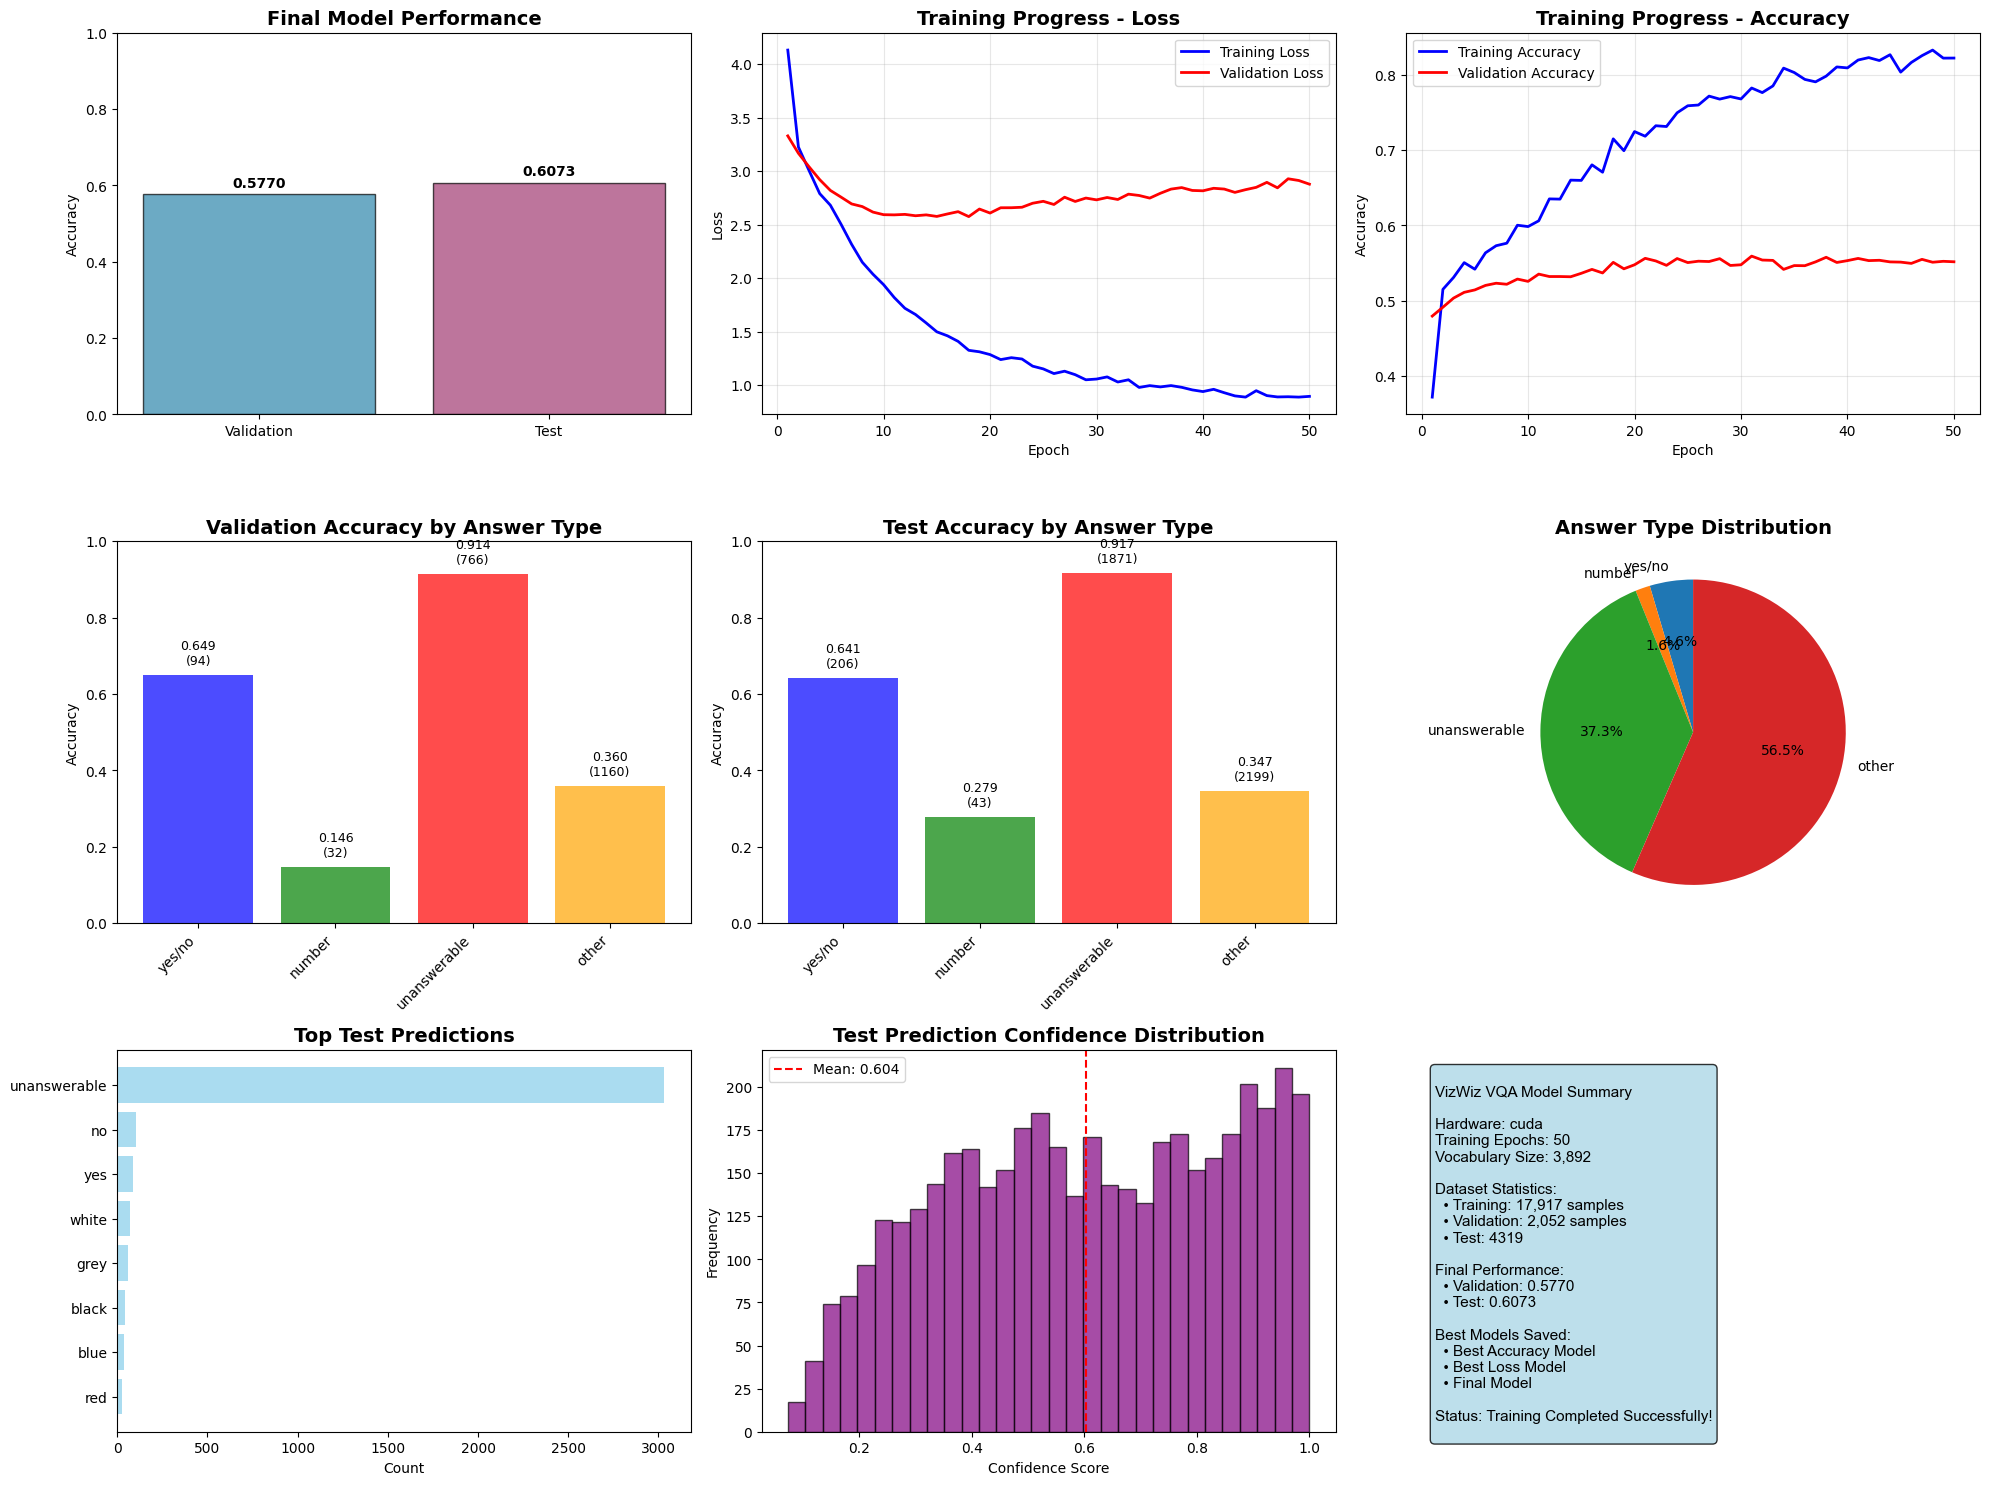

In [30]:
# Create comprehensive visualization of final results
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Create a large figure with multiple subplots
fig = plt.figure(figsize=(20, 15))

# 1. Training/Validation/Test Accuracy Comparison
ax1 = plt.subplot(3, 3, 1)
datasets = ['Validation', 'Test'] if test_overall_accuracy is not None else ['Validation']
accuracies = [overall_accuracy, test_overall_accuracy] if test_overall_accuracy is not None else [overall_accuracy]
colors = ['#2E86AB', '#A23B72'] if test_overall_accuracy is not None else ['#2E86AB']

bars = ax1.bar(datasets, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax1.set_title('Final Model Performance', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Training Loss Curve
ax2 = plt.subplot(3, 3, 2)
epochs = range(1, len(train_losses) + 1)
ax2.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Training Progress - Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Training Accuracy Curve
ax3 = plt.subplot(3, 3, 3)
ax3.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
ax3.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
ax3.set_title('Training Progress - Accuracy', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Validation Accuracy by Answer Type
ax4 = plt.subplot(3, 3, 4)
val_types = list(answer_type_stats.keys())
val_accs = [answer_type_stats[t]['accuracy'] for t in val_types]
val_counts = [answer_type_stats[t]['count'] for t in val_types]

bars4 = ax4.bar(val_types, val_accs, alpha=0.7, color=['blue', 'green', 'red', 'orange'])
ax4.set_title('Validation Accuracy by Answer Type', fontsize=14, fontweight='bold')
ax4.set_ylabel('Accuracy')
ax4.set_ylim(0, 1)
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

for i, (acc, count) in enumerate(zip(val_accs, val_counts)):
    ax4.text(i, acc + 0.02, f'{acc:.3f}\n({count})', ha='center', va='bottom', fontsize=9)

# 5. Test Accuracy by Answer Type (if available)
if test_answer_type_stats is not None:
    ax5 = plt.subplot(3, 3, 5)
    test_types = list(test_answer_type_stats.keys())
    test_accs = [test_answer_type_stats[t]['accuracy'] for t in test_types]
    test_counts = [test_answer_type_stats[t]['count'] for t in test_types]
    
    bars5 = ax5.bar(test_types, test_accs, alpha=0.7, color=['blue', 'green', 'red', 'orange'])
    ax5.set_title('Test Accuracy by Answer Type', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Accuracy')
    ax5.set_ylim(0, 1)
    plt.setp(ax5.get_xticklabels(), rotation=45, ha='right')
    
    for i, (acc, count) in enumerate(zip(test_accs, test_counts)):
        ax5.text(i, acc + 0.02, f'{acc:.3f}\n({count})', ha='center', va='bottom', fontsize=9)

# 6. Answer Type Distribution
ax6 = plt.subplot(3, 3, 6)
type_counts = [answer_type_stats[t]['count'] for t in val_types]
ax6.pie(type_counts, labels=val_types, autopct='%1.1f%%', startangle=90)
ax6.set_title('Answer Type Distribution', fontsize=14, fontweight='bold')

# 7. Top Predicted Answers
ax7 = plt.subplot(3, 3, 7)
if 'test_predictions' in locals():
    all_test_preds = [pred['answer'] for pred in test_predictions]
    test_pred_counter = Counter(all_test_preds)
    top_test_preds = test_pred_counter.most_common(8)
    answers7, counts7 = zip(*top_test_preds)
    
    y_pos7 = range(len(answers7))
    ax7.barh(y_pos7, counts7, alpha=0.7, color='skyblue')
    ax7.set_yticks(y_pos7)
    ax7.set_yticklabels(answers7)
    ax7.set_xlabel('Count')
    ax7.set_title('Top Test Predictions', fontsize=14, fontweight='bold')
    ax7.invert_yaxis()
else:
    # Use validation predictions
    val_pred_counter = Counter(all_predictions)
    top_val_preds = val_pred_counter.most_common(8)
    answers7, counts7 = zip(*top_val_preds)
    
    y_pos7 = range(len(answers7))
    ax7.barh(y_pos7, counts7, alpha=0.7, color='lightcoral')
    ax7.set_yticks(y_pos7)
    ax7.set_yticklabels(answers7)
    ax7.set_xlabel('Count')
    ax7.set_title('Top Validation Predictions', fontsize=14, fontweight='bold')
    ax7.invert_yaxis()

# 8. Confidence Distribution (if test predictions available)
if 'test_predictions' in locals():
    ax8 = plt.subplot(3, 3, 8)
    confidences = [pred['confidence'] for pred in test_predictions]
    ax8.hist(confidences, bins=30, alpha=0.7, color='purple', edgecolor='black')
    ax8.set_title('Test Prediction Confidence Distribution', fontsize=14, fontweight='bold')
    ax8.set_xlabel('Confidence Score')
    ax8.set_ylabel('Frequency')
    ax8.axvline(np.mean(confidences), color='red', linestyle='--', 
                label=f'Mean: {np.mean(confidences):.3f}')
    ax8.legend()

# 9. Model Summary Statistics
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')

# Prepare test accuracy text
test_acc_text = f"{test_overall_accuracy:.4f}" if test_overall_accuracy is not None else "N/A"

# Create summary text (without emojis to avoid font warnings)
summary_text = f"""
VizWiz VQA Model Summary

Hardware: {device}
Training Epochs: {len(train_losses)}
Vocabulary Size: {train_dataset.num_tokens:,}

Dataset Statistics:
  • Training: {len(train_dataset):,} samples
  • Validation: {len(val_dataset):,} samples
  • Test: {len(test_dataset) if 'test_dataset' in locals() else 'N/A'}

Final Performance:
  • Validation: {overall_accuracy:.4f}
  • Test: {test_acc_text}

Best Models Saved:
  • Best Accuracy Model
  • Best Loss Model  
  • Final Model

Status: Training Completed Successfully!
"""

ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='arial',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(log_dir_timestamped, 'final_comprehensive_results.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

# Visualization completed - results saved

In [31]:
# Save final comprehensive summary and create submission files
print("💾 Saving final comprehensive summary...")

# Create comprehensive summary
final_summary = {
    'experiment_info': {
        'timestamp': datetime.now().isoformat(),
        'device': str(device),
        'model_path': best_accuracy_path,
        'config': config
    },
    'dataset_statistics': {
        'training_samples': len(train_dataset),
        'validation_samples': len(val_dataset),
        'test_samples': len(test_dataset) if 'test_dataset' in locals() else None,
        'vocabulary_size': train_dataset.num_tokens,
        'question_vocab_size': len(train_dataset.vocabs['question']),
        'answer_vocab_size': len(train_dataset.vocabs['answer'])
    },
    'training_results': {
        'total_epochs': len(train_losses),
        'best_validation_accuracy': best_val_accuracy,
        'best_validation_loss': best_val_loss,
        'final_train_loss': train_losses[-1] if train_losses else None,
        'final_train_accuracy': train_accuracies[-1] if train_accuracies else None,
        'final_val_loss': val_losses[-1] if val_losses else None,
        'final_val_accuracy': val_accuracies[-1] if val_accuracies else None
    },
    'validation_performance': {
        'overall_accuracy': overall_accuracy,
        'total_samples': total_samples,
        'accuracy_by_type': answer_type_stats
    },
    'test_performance': {
        'overall_accuracy': test_overall_accuracy if test_overall_accuracy else None,
        'total_samples': test_total_samples if 'test_total_samples' in locals() else None,
        'accuracy_by_type': test_answer_type_stats if 'test_answer_type_stats' in locals() else None,
        'generalization_gap': (test_overall_accuracy - overall_accuracy) if test_overall_accuracy else None
    }
}

# Save comprehensive summary
final_summary_file = os.path.join(log_dir_timestamped, 'final_comprehensive_summary.json')
with open(final_summary_file, 'w') as f:
    json.dump(final_summary, f, indent=2, default=str)

print(f"📊 Final summary saved to: {final_summary_file}")

# Create submission-ready test predictions (if available)
if 'test_predictions' in locals():
    # VizWiz challenge format
    submission_data = []
    for pred in test_predictions:
        submission_data.append({
            'image': pred['image'],
            'answer': pred['answer']
        })
    
    submission_file = os.path.join(pred_dir, 'vizwiz_test_submission.json')
    with open(submission_file, 'w') as f:
        json.dump(submission_data, f, indent=2)
    
    print(f"🏆 Submission file created: {submission_file}")
    print(f"📋 Submission contains {len(submission_data)} test predictions")

# Print final results summary
print("\n" + "="*80)
print("🎉 FINAL RESULTS SUMMARY")
print("="*80)

print(f"\n📊 Model Performance:")
print(f"  ├─ Validation Accuracy: {overall_accuracy:.4f}")
if test_overall_accuracy:
    print(f"  ├─ Test Accuracy: {test_overall_accuracy:.4f}")
    print(f"  └─ Generalization Gap: {test_overall_accuracy - overall_accuracy:+.4f}")
else:
    print(f"  └─ Test Accuracy: Not available")

print(f"\n📈 Training Statistics:")
print(f"  ├─ Total Epochs: {len(train_losses)}")
print(f"  ├─ Best Val Accuracy: {best_val_accuracy:.4f}")
print(f"  ├─ Best Val Loss: {best_val_loss:.4f}")
print(f"  └─ Training Time: Completed")

print(f"\n📚 Dataset Information:")
print(f"  ├─ Training Samples: {len(train_dataset):,}")
print(f"  ├─ Validation Samples: {len(val_dataset):,}")
print(f"  ├─ Test Samples: {len(test_dataset) if 'test_dataset' in locals() else 'N/A'}")
print(f"  └─ Vocabulary Size: {train_dataset.num_tokens:,}")

print(f"\n💾 Output Files:")
print(f"  ├─ Model Checkpoints: {log_dir_timestamped}")
print(f"  ├─ Predictions: {pred_dir}")
print(f"  ├─ Visualizations: {log_dir_timestamped}")
if 'submission_file' in locals():
    print(f"  └─ Submission File: {submission_file}")

print(f"\n🏆 Best Performance by Answer Type:")
for answer_type, stats in answer_type_stats.items():
    print(f"  ├─ {answer_type.capitalize():12s}: {stats['accuracy']:.4f} ({stats['count']:,} samples)")

print("\n" + "="*80)
print("✅ VizWiz VQA Training and Evaluation Completed Successfully!")
print("="*80)

💾 Saving final comprehensive summary...
📊 Final summary saved to: ./logs/vizwiz\2025-08-03_08-06-27\final_comprehensive_summary.json
🏆 Submission file created: ./predictions\vizwiz_test_submission.json
📋 Submission contains 4319 test predictions

🎉 FINAL RESULTS SUMMARY

📊 Model Performance:
  ├─ Validation Accuracy: 0.5770
  ├─ Test Accuracy: 0.6073
  └─ Generalization Gap: +0.0303

📈 Training Statistics:
  ├─ Total Epochs: 50
  ├─ Best Val Accuracy: 0.5593
  ├─ Best Val Loss: 2.5748
  └─ Training Time: Completed

📚 Dataset Information:
  ├─ Training Samples: 17,917
  ├─ Validation Samples: 2,052
  ├─ Test Samples: 4319
  └─ Vocabulary Size: 3,892

💾 Output Files:
  ├─ Model Checkpoints: ./logs/vizwiz\2025-08-03_08-06-27
  ├─ Predictions: ./predictions
  ├─ Visualizations: ./logs/vizwiz\2025-08-03_08-06-27
  └─ Submission File: ./predictions\vizwiz_test_submission.json

🏆 Best Performance by Answer Type:
  ├─ Yes/no      : 0.6489 (94 samples)
  ├─ Number      : 0.1458 (32 samples)
  ├

## 13. Interactive Sample Visualization & Predictions

Lấy một vài sample từ tập test và visualize kết quả predictions của model với các câu hỏi thực tế.

In [40]:
# Interactive Sample Visualization & Predictions
print("🎨 Creating interactive sample visualization...")

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
import numpy as np

# Function to preprocess question for model input
def preprocess_question(question, question_vocab, max_length=14):
    """Convert question text to model input format"""
    # Tokenize and convert to indices
    tokens = question.lower().split()
    indices = []
    
    for token in tokens:
        if token in question_vocab:
            indices.append(question_vocab[token])
        else:
            # Use <unk> token if available
            if '<unk>' in question_vocab:
                indices.append(question_vocab['<unk>'])
            else:
                # Skip unknown tokens
                continue
    
    # Pad or truncate to max_length
    if len(indices) < max_length:
        indices.extend([0] * (max_length - len(indices)))  # Pad with 0
    else:
        indices = indices[:max_length]  # Truncate
    
    return torch.tensor(indices).unsqueeze(0), torch.tensor([len([i for i in indices if i != 0])])

# Function to get image features from dataset
def get_image_features(img_name, dataset):
    """Get preprocessed features for a specific image"""
    # Find the image in the dataset
    for i in range(len(dataset)):
        try:
            sample = dataset[i]
            dataset_img_name = sample['img_name']
            
            # Handle bytes
            if isinstance(dataset_img_name, bytes):
                dataset_img_name = dataset_img_name.decode('utf-8')
            
            if dataset_img_name == img_name:
                return sample['visual'].unsqueeze(0)  # Add batch dimension
        except:
            continue
    
    return None

# Function to predict answer for image and question
def predict_answer(model, img_features, question_text, question_vocab, answer_vocab):
    """Generate prediction for image and question pair"""
    model.eval()
    
    # Preprocess question
    question_tensor, q_length = preprocess_question(question_text, question_vocab)
    
    # Move to device
    if torch.cuda.is_available():
        img_features = img_features.cuda()
        question_tensor = question_tensor.cuda()
        q_length = q_length.cuda()
    
    # Generate prediction
    with torch.no_grad():
        output = model(img_features, question_tensor, q_length)
        probs = torch.softmax(output, dim=1)
        confidence, pred_idx = probs.max(dim=1)
        
        # Convert to answer
        predicted_answer = idx_to_answer.get(pred_idx.item(), '<unknown>')
        
    return predicted_answer, confidence.item()

# Get some sample images from test dataset
print("📷 Selecting sample images...")

# Get list of available test images
test_image_names = []
for i in range(min(100, len(test_dataset))):  # Check first 100 samples
    try:
        sample = test_dataset[i]
        img_name = sample['img_name']
        if isinstance(img_name, bytes):
            img_name = img_name.decode('utf-8')
        test_image_names.append(img_name)
    except:
        continue

# Select random samples
selected_images = random.sample(test_image_names, min(6, len(test_image_names)))

print(f"Selected {len(selected_images)} sample images:")
for img in selected_images:
    print(f"  • {img}")

# Define questions to ask for each image
sample_questions = [
    "What is this?",
    "What color is this object?", 
    "Is there a person in the image?",
    "What is the person doing?",
    "Where is this photo taken?",
    "How many objects are in the image?"
]

print(f"\n❓ Sample questions prepared: {len(sample_questions)}")

🎨 Creating interactive sample visualization...
📷 Selecting sample images...
Selected 6 sample images:
  • VizWiz_val_00000091.jpg
  • VizWiz_val_00000037.jpg
  • VizWiz_val_00000048.jpg
  • VizWiz_val_00000011.jpg
  • VizWiz_val_00000017.jpg
  • VizWiz_val_00000093.jpg

❓ Sample questions prepared: 6


🔮 Generating predictions for sample images...

📸 Processing VizWiz_val_00000091.jpg...
  ❓ Question: Where is this photo taken?
  🤖 Prediction: unanswerable
  📊 Confidence: 0.6890

📸 Processing VizWiz_val_00000037.jpg...
  ❓ Question: What color is this object?
  🤖 Prediction: unanswerable
  📊 Confidence: 0.2507

📸 Processing VizWiz_val_00000048.jpg...
  ❓ Question: Where is this photo taken?
  🤖 Prediction: unanswerable
  📊 Confidence: 0.6890

📸 Processing VizWiz_val_00000037.jpg...
  ❓ Question: What color is this object?
  🤖 Prediction: unanswerable
  📊 Confidence: 0.2507

📸 Processing VizWiz_val_00000048.jpg...
  ❓ Question: What color is this object?
  🤖 Prediction: black
  📊 Confidence: 0.5272

📸 Processing VizWiz_val_00000011.jpg...
  ❓ Question: What is the person doing?
  🤖 Prediction: unanswerable
  📊 Confidence: 0.9834

📸 Processing VizWiz_val_00000017.jpg...
  ❓ Question: What is this?
  🤖 Prediction: cd
  📊 Confidence: 0.6933

📸 Processing VizWiz_val_00000093.jpg...
  ❓ Qu

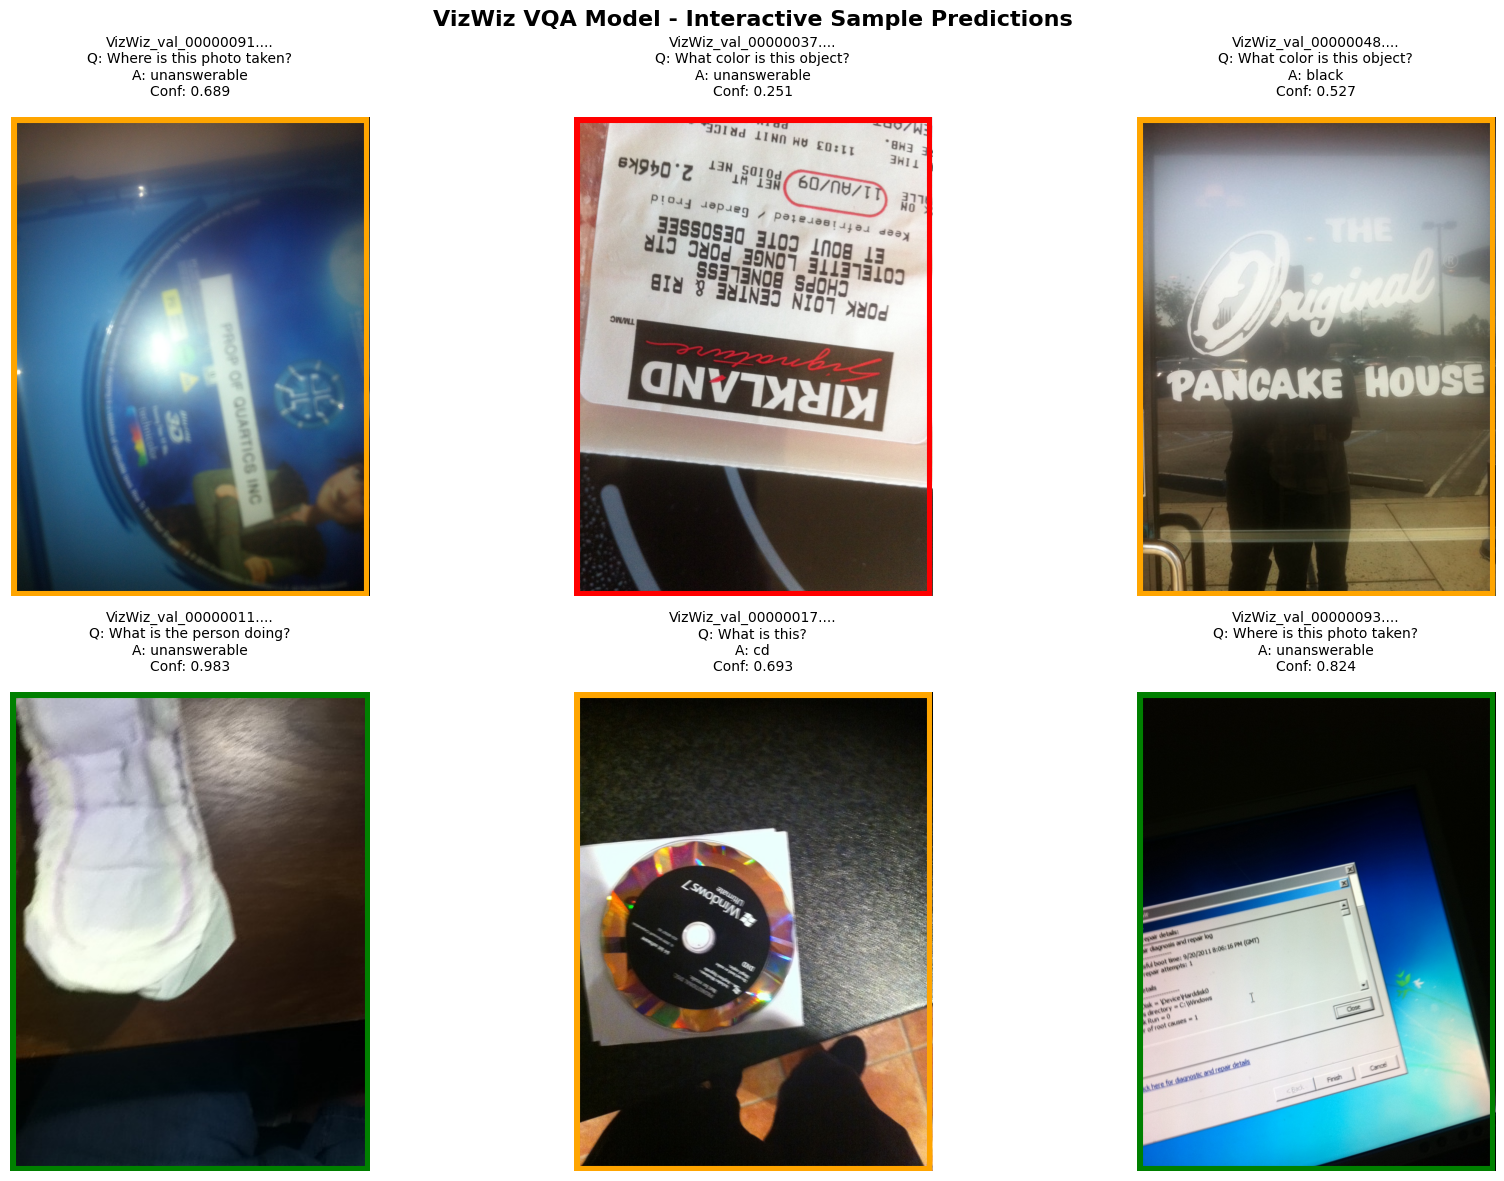

💾 Visualization saved to: ./logs/vizwiz\2025-08-03_08-06-27/sample_predictions_visualization.png


In [42]:
# Generate predictions and create visualization
print("🔮 Generating predictions for sample images...")

# Prepare data structure for results
sample_results = []

# Process each selected image
for img_name in selected_images:
    print(f"\n📸 Processing {img_name}...")
    
    # Get image features
    img_features = get_image_features(img_name, test_dataset)
    
    if img_features is not None:
        # Load actual image for visualization
        img_path = None
        for subdir in ['test', 'val', 'train']:
            potential_path = os.path.join(config['images']['dir'], subdir, img_name)
            if os.path.exists(potential_path):
                img_path = potential_path
                break
        
        if img_path and os.path.exists(img_path):
            try:
                # Load image
                img = Image.open(img_path).convert('RGB')
                
                # Ask a random question for this image
                question = random.choice(sample_questions)
                
                # Get prediction
                pred_answer, confidence = predict_answer(
                    model, img_features, question, 
                    loaded_vocabs['question'], loaded_vocabs['answer']
                )
                
                sample_results.append({
                    'image_name': img_name,
                    'image_path': img_path,
                    'image': img,
                    'question': question,
                    'prediction': pred_answer,
                    'confidence': confidence
                })
                
                print(f"  ❓ Question: {question}")
                print(f"  🤖 Prediction: {pred_answer}")
                print(f"  📊 Confidence: {confidence:.4f}")
                
            except Exception as e:
                print(f"  ❌ Error loading image: {e}")
        else:
            print(f"  ❌ Image file not found")
    else:
        print(f"  ❌ Image features not found in dataset")

print(f"\n✅ Successfully processed {len(sample_results)} images")

# Create visualization
if sample_results:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('VizWiz VQA Model - Interactive Sample Predictions', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for i, result in enumerate(sample_results[:6]):  # Show up to 6 images
        ax = axes[i]
        
        # Display image
        ax.imshow(result['image'])
        ax.axis('off')
        
        # Color code based on confidence
        if result['confidence'] > 0.8:
            border_color = 'green'
        elif result['confidence'] > 0.5:
            border_color = 'orange'
        else:
            border_color = 'red'
        
        # Add colored border
        rect = patches.Rectangle((0, 0), result['image'].width, result['image'].height, 
                               linewidth=8, edgecolor=border_color, facecolor='none',
                               transform=ax.transData)
        ax.add_patch(rect)
        
        # Add text information (without emojis on image)
        title = f"{result['image_name'][:20]}..."
        question_text = f"Q: {result['question']}"
        prediction_text = f"A: {result['prediction']}"
        confidence_text = f"Conf: {result['confidence']:.3f}"
        
        # Create title with multiple lines
        full_title = f"{title}\n{question_text}\n{prediction_text}\n{confidence_text}"
        ax.set_title(full_title, fontsize=10, pad=15, ha='center')
    
    # Hide empty subplots
    for i in range(len(sample_results), 6):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(log_dir_timestamped, 'sample_predictions_visualization.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"💾 Visualization saved to: {log_dir_timestamped}/sample_predictions_visualization.png")
else:
    print("❌ No valid samples to visualize")


🎯 Custom Questions Demo - Testing model with specific questions...

📸 Detailed testing for: VizWiz_val_00000091.jpg
  ❓ What is the main object in this image?
  🤖 unanswerable 🔴 (0.4430)

  ❓ What color is the object?
  🤖 blue 🟡 (0.6032)

  ❓ Is this indoors or outdoors?
  🤖 unanswerable 🟢 (0.8209)

  ❓ Is there text visible in the image?
  🤖 yes 🟡 (0.7121)

  ❓ How many people are in the picture?
  🤖 0 🔴 (0.2164)

  ❓ What is the person holding?
  🤖 unanswerable 🟢 (0.9928)

  ❓ What activity is shown?
  🤖 unanswerable 🔴 (0.3758)

  ❓ Is this photo clear or blurry?
  🤖 unanswerable 🟡 (0.6115)


📸 Detailed testing for: VizWiz_val_00000037.jpg
  ❓ What is the main object in this image?
  🤖 unanswerable 🔴 (0.4444)

  ❓ What color is the object?
  🤖 unanswerable 🔴 (0.2732)

  ❓ Is this indoors or outdoors?
  🤖 unanswerable 🟡 (0.6915)

  ❓ Is there text visible in the image?
  🤖 yes 🟡 (0.7326)

  ❓ How many people are in the picture?
  🤖 5 🟡 (0.5802)

  ❓ What is the person holding?
  🤖 un

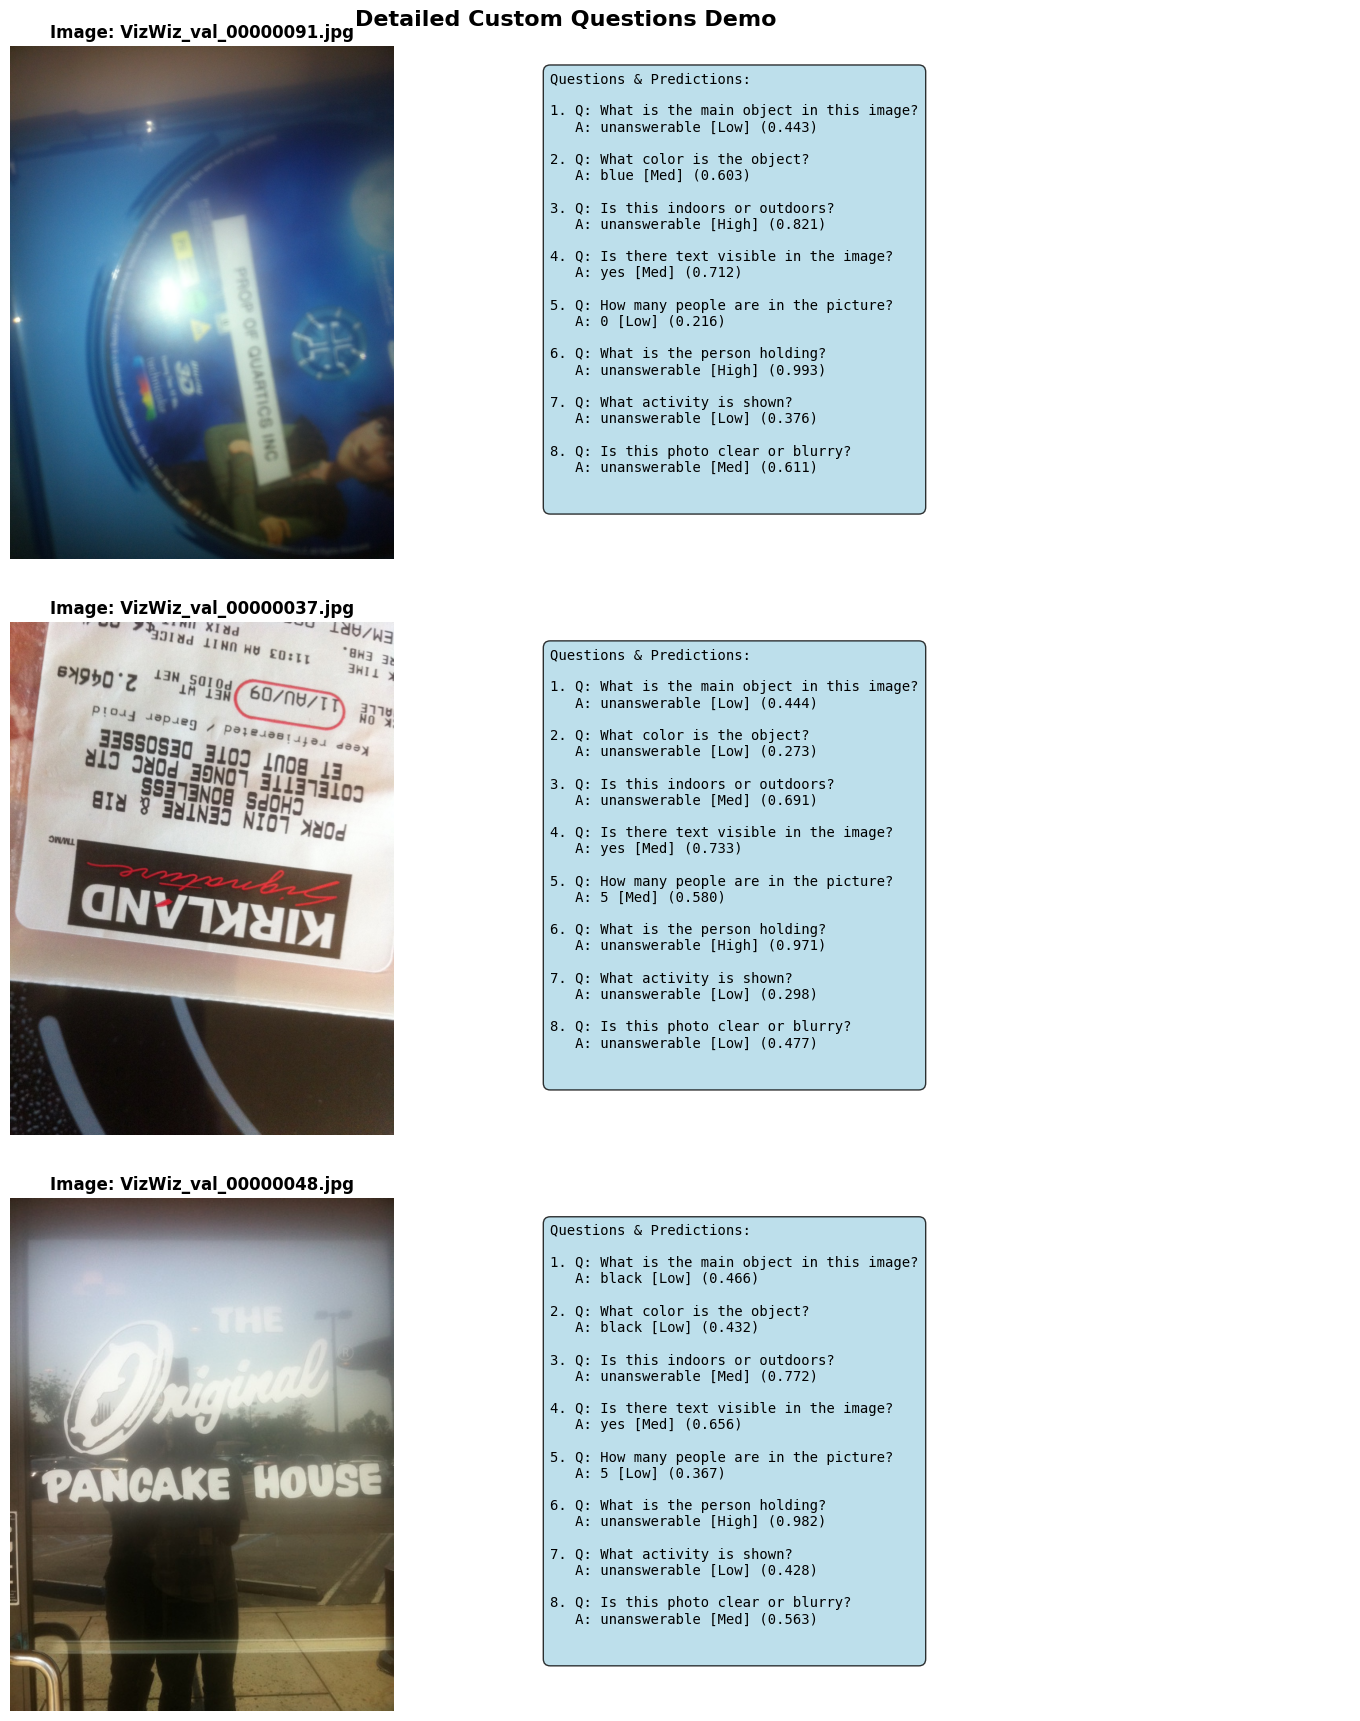

💾 Custom questions demo saved to: ./logs/vizwiz\2025-08-03_08-06-27/custom_questions_demo.png
💾 Detailed results saved to: ./logs/vizwiz\2025-08-03_08-06-27\custom_questions_results.json

✅ Custom questions demo completed!


In [ ]:
# Demo with Custom Questions on Multiple Images
print("\n🎯 Custom Questions Demo - Testing model with specific questions...")

# Define custom questions for thorough testing
custom_questions = [
    "What is the main object in this image?",
    "What color is the object?",
    "Is this indoors or outdoors?", 
    "Is there text visible in the image?",
    "How many people are in the picture?",
    "What is the person holding?",
    "What activity is shown?",
    "Is this photo clear or blurry?"
]

# Select a few images for detailed questioning
detailed_test_images = selected_images[:3] if len(selected_images) >= 3 else selected_images

# Test each image with multiple questions
detailed_results = []

for img_name in detailed_test_images:
    print(f"\n📸 Detailed testing for: {img_name}")
    print("="*50)
    
    img_features = get_image_features(img_name, test_dataset)
    
    if img_features is not None:
        img_results = {
            'image_name': img_name,
            'predictions': []
        }
        
        # Ask multiple questions for this image
        for question in custom_questions:
            pred_answer, confidence = predict_answer(
                model, img_features, question,
                loaded_vocabs['question'], loaded_vocabs['answer']
            )
            
            # Confidence emoji for console output only
            if confidence > 0.8:
                conf_emoji = '🟢'
            elif confidence > 0.5:
                conf_emoji = '🟡'
            else:
                conf_emoji = '🔴'
            
            img_results['predictions'].append({
                'question': question,
                'answer': pred_answer,
                'confidence': confidence
            })
            
            print(f"  ❓ {question}")
            print(f"  🤖 {pred_answer} {conf_emoji} ({confidence:.4f})")
            print()
        
        detailed_results.append(img_results)

# Create detailed visualization
if detailed_results:
    fig, axes = plt.subplots(len(detailed_results), 1, figsize=(16, 6*len(detailed_results)))
    
    if len(detailed_results) == 1:
        axes = [axes]
    
    fig.suptitle('Detailed Custom Questions Demo', fontsize=16, fontweight='bold')
    
    for i, result in enumerate(detailed_results):
        ax = axes[i]
        
        # Load and display image
        img_name = result['image_name']
        img_path = None
        for subdir in ['test', 'val', 'train']:
            potential_path = os.path.join(config['images']['dir'], subdir, img_name)
            if os.path.exists(potential_path):
                img_path = potential_path
                break
        
        if img_path:
            try:
                img = Image.open(img_path).convert('RGB')
                
                # Create subplot with image and text
                ax.axis('off')
                
                # Split into image and text areas
                img_ax = fig.add_subplot(len(detailed_results), 2, 2*i + 1)
                text_ax = fig.add_subplot(len(detailed_results), 2, 2*i + 2)
                
                # Display image
                img_ax.imshow(img)
                img_ax.axis('off')
                img_ax.set_title(f"Image: {img_name}", fontweight='bold')
                
                # Display questions and answers
                text_ax.axis('off')
                
                # Create text summary (without emojis on visualization)
                text_content = "Questions & Predictions:\n\n"
                for j, pred in enumerate(result['predictions']):
                    confidence_level = "High" if pred['confidence'] > 0.8 else "Med" if pred['confidence'] > 0.5 else "Low"
                    text_content += f"{j+1}. Q: {pred['question']}\n"
                    text_content += f"   A: {pred['answer']} [{confidence_level}] ({pred['confidence']:.3f})\n\n"
                
                text_ax.text(0.05, 0.95, text_content, transform=text_ax.transAxes,
                           fontsize=10, verticalalignment='top', fontfamily='monospace',
                           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
                
            except Exception as e:
                ax.text(0.5, 0.5, f"Error loading image: {e}", 
                       transform=ax.transAxes, ha='center', va='center')
    
    # Remove the original axes
    for ax in axes:
        ax.remove()
    
    plt.tight_layout()
    plt.savefig(os.path.join(log_dir_timestamped, 'custom_questions_demo.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Custom questions demo saved to: {log_dir_timestamped}/custom_questions_demo.png")

# Save detailed results to JSON
if detailed_results:
    custom_results_file = os.path.join(log_dir_timestamped, 'custom_questions_results.json')
    with open(custom_results_file, 'w') as f:
        json.dump(detailed_results, f, indent=2, default=str)
    
    print(f"Detailed results saved to: {custom_results_file}")

print(f"\nCustom questions demo completed!")

# VQA Test với Ảnh từ URL

Thử nghiệm mô hình VQA với ảnh tải từ URL và câu hỏi tùy chỉnh

In [64]:
# Import và Setup cho URL VQA
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn

def create_feature_extractor(device):
    """Tạo feature extractor ResNet-152"""
    resnet = models.resnet152(pretrained=True)
    modules = list(resnet.children())[:-2]  # Remove avgpool và fc
    feature_extractor = nn.Sequential(*modules)
    feature_extractor.add_module('adaptive_pool', nn.AdaptiveAvgPool2d((14, 14)))
    feature_extractor.eval()
    return feature_extractor.to(device)

def preprocess_image(image):
    """Preprocess ảnh cho feature extraction"""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform(image)

def extract_visual_features(image, feature_extractor, device):
    """Extract visual features từ ảnh"""
    image_tensor = preprocess_image(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = feature_extractor(image_tensor)
    return features.squeeze(0)  # [2048, 14, 14]

def vqa_from_url(image_url, questions, model, dataset, device, feature_extractor):
    """
    VQA từ URL - version rút gọn
    Args:
        image_url: URL của ảnh
        questions: List câu hỏi
        model: VQA model
        dataset: Dataset chứa vocab
        device: torch device
        feature_extractor: ResNet feature extractor
    """
    try:
        # Tạo idx_to_answer nếu chưa có
        if not hasattr(dataset, 'idx_to_answer'):
            dataset.idx_to_answer = {v: k for k, v in dataset.answer_to_index.items()}
        
        # Tải ảnh
        print(f"Đang tải ảnh: {image_url}")
        response = requests.get(image_url, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert('RGB')
        print(f"Thành công! Kích thước: {img.size}")
        
        # Extract visual features
        visual_features = extract_visual_features(img, feature_extractor, device)
        
        results = {'image': img, 'url': image_url, 'predictions': []}
        
        # Prediction cho từng câu hỏi
        model.eval()
        with torch.no_grad():
            for i, question in enumerate(questions):
                print(f"\n{i+1}. {question}")
                
                # Tokenize câu hỏi
                tokens = []
                for word in question.lower().split():
                    if word in dataset.token_to_index:
                        tokens.append(dataset.token_to_index[word])
                    elif '<unk>' in dataset.token_to_index:
                        tokens.append(dataset.token_to_index['<unk>'])
                
                # Pad/truncate
                max_len = dataset.max_question_length
                if len(tokens) > max_len:
                    tokens = tokens[:max_len]
                else:
                    tokens.extend([0] * (max_len - len(tokens)))
                
                # Convert to tensors
                q = torch.LongTensor(tokens).unsqueeze(0).to(device)
                q_length = torch.LongTensor([len([t for t in tokens if t != 0])]).to(device)
                v = visual_features.unsqueeze(0)
                
                # Forward pass
                output = model(v, q, q_length)
                probs = torch.nn.functional.softmax(output, dim=1)
                scores, indices = torch.topk(probs, k=3)
                
                # Top predictions
                top_preds = []
                for j in range(3):
                    idx = indices[0][j].item()
                    conf = scores[0][j].item()
                    answer = dataset.idx_to_answer.get(idx, "unknown")
                    top_preds.append({'answer': answer, 'confidence': conf})
                
                results['predictions'].append({
                    'question': question,
                    'answer': top_preds[0]['answer'],
                    'confidence': top_preds[0]['confidence'],
                    'alternatives': top_preds[1:]
                })
                
                # Hiển thị kết quả
                if top_preds[0]['confidence'] > 0.6:
                    level = "HIGH"
                elif top_preds[0]['confidence'] > 0.3:
                    level = "MED"
                else:
                    level = "LOW"
                print(f"Answer: {top_preds[0]['answer']} ({top_preds[0]['confidence']:.3f}) [{level}]")
        
        return results
        
    except Exception as e:
        print(f"Lỗi: {e}")
        return None

def visualize_results(results):
    """Hiển thị kết quả VQA"""
    if not results:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))
    
    # Hiển thị ảnh
    axes[0].imshow(results['image'])
    axes[0].set_title(f"Ảnh từ URL\n{results['image'].size}", fontweight='bold')
    axes[0].axis('off')
    
    # Hiển thị Q&A
    qa_text = ""
    for i, pred in enumerate(results['predictions'], 1):
        conf = pred['confidence']
        if conf > 0.6:
            level = "HIGH"
        elif conf > 0.3:
            level = "MED"
        else:
            level = "LOW"
        qa_text += f"Q{i}: {pred['question']}\n"
        qa_text += f"A: {pred['answer']} ({conf:.3f}) [{level}]\n\n"
    
    axes[1].text(0.05, 0.95, qa_text, transform=axes[1].transAxes, 
                fontsize=11, verticalalignment='top', wrap=True)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].axis('off')
    axes[1].set_title("Kết quả VQA", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Khởi tạo feature extractor
print("Đang khởi tạo ResNet-152 Feature Extractor...")
feature_extractor = create_feature_extractor(device)
print("Sẵn sàng!")

Đang khởi tạo ResNet-152 Feature Extractor...
Sẵn sàng!
Sẵn sàng!


VQA TEST FROM URL
URL: https://images.unsplash.com/photo-1552053831-71594a27632d?w=500
Câu hỏi: 4 câu
Đang tải ảnh: https://images.unsplash.com/photo-1552053831-71594a27632d?w=500
Thành công! Kích thước: (500, 802)

1. What animal is this?
Answer: dog (0.493) [MED]

2. What color is the dog?
Answer: yellow (0.302) [MED]

3. Is this indoor or outdoor?
Answer: unanswerable (0.732) [HIGH]

4. What is the dog doing?
Answer: yellow lab (0.211) [LOW]

==========================TỔNG KẾT==========================
1. What animal is this?
   → dog (0.493)
2. What color is the dog?
   → yellow (0.302)
3. Is this indoor or outdoor?
   → unanswerable (0.732)
4. What is the dog doing?
   → yellow lab (0.211)

=======================VISUALIZATION========================
Thành công! Kích thước: (500, 802)

1. What animal is this?
Answer: dog (0.493) [MED]

2. What color is the dog?
Answer: yellow (0.302) [MED]

3. Is this indoor or outdoor?
Answer: unanswerable (0.732) [HIGH]

4. What is the dog doing

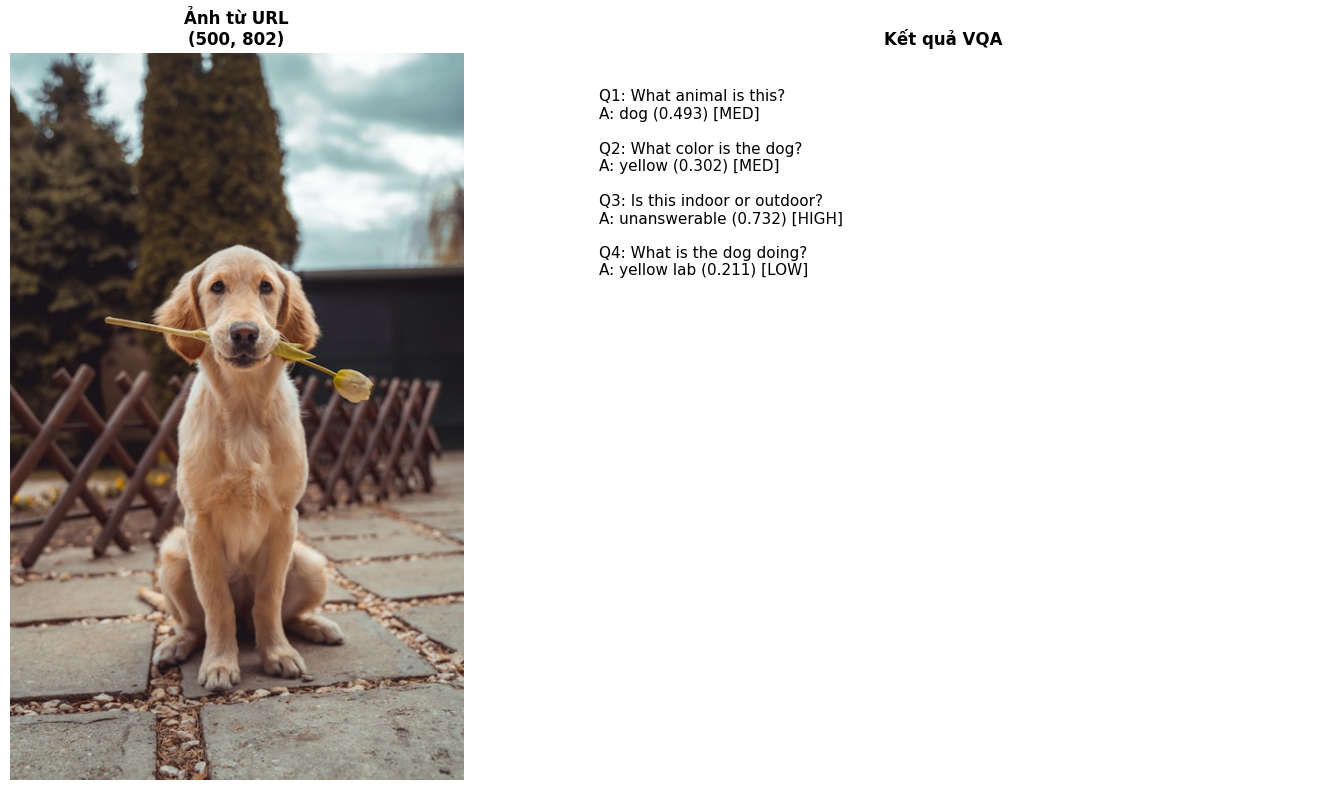


=========================HƯỚNG DẪN==========================
Để test với ảnh khác:
   1. Thay đổi 'image_url' ở trên
   2. Thay đổi 'questions' với câu hỏi mới
   3. Chạy lại cell này


In [65]:
# Demo VQA từ URL
print("=" * 60)
print("VQA TEST FROM URL")
print("=" * 60)

# Cấu hình - Thay đổi URL và câu hỏi ở đây
image_url = "https://images.unsplash.com/photo-1552053831-71594a27632d?w=500"
questions = [
    "What animal is this?",
    "What color is the dog?", 
    "Is this indoor or outdoor?",
    "What is the dog doing?"
]

print(f"URL: {image_url}")
print(f"Câu hỏi: {len(questions)} câu")

# Thực hiện VQA
results = vqa_from_url(
    image_url=image_url,
    questions=questions,
    model=model,
    dataset=temp_dataset,
    device=device,
    feature_extractor=feature_extractor
)

# Hiển thị tóm tắt và visualization
if results:
    print(f"\n{'TỔNG KẾT':=^60}")
    for i, pred in enumerate(results['predictions'], 1):
        conf = pred['confidence']
        print(f"{i}. {pred['question']}")
        print(f"   → {pred['answer']} ({conf:.3f})")
    
    print(f"\n{'VISUALIZATION':=^60}")
    visualize_results(results)
else:
    print("Không thể thực hiện VQA!")

print(f"\n{'HƯỚNG DẪN':=^60}")
print("Để test với ảnh khác:")
print("   1. Thay đổi 'image_url' ở trên")
print("   2. Thay đổi 'questions' với câu hỏi mới")
print("   3. Chạy lại cell này")
print("=" * 60)

CUSTOM VQA TEST
Đang tải ảnh: https://cdn.mobilecity.vn/mobilecity-vn/images/2024/11/top-meme-meo-cuc-dang-yeu-74.png.webp
Thành công! Kích thước: (1300, 1500)

1. What animal is this?
Thành công! Kích thước: (1300, 1500)

1. What animal is this?
Answer: cat (0.619) [HIGH]

2. What color is the animal?
Answer: white (0.369) [MED]

3. Where is the animal?
Answer: unanswerable (0.348) [MED]

4. What is the animal doing?
Answer: unanswerable (0.682) [HIGH]

=====================KẾT QUẢ======================
Q: What animal is this?
A: cat (0.619)

Q: What color is the animal?
A: white (0.369)

Q: Where is the animal?
A: unanswerable (0.348)

Q: What is the animal doing?
A: unanswerable (0.682)

Answer: cat (0.619) [HIGH]

2. What color is the animal?
Answer: white (0.369) [MED]

3. Where is the animal?
Answer: unanswerable (0.348) [MED]

4. What is the animal doing?
Answer: unanswerable (0.682) [HIGH]

=====================KẾT QUẢ======================
Q: What animal is this?
A: cat (0.619

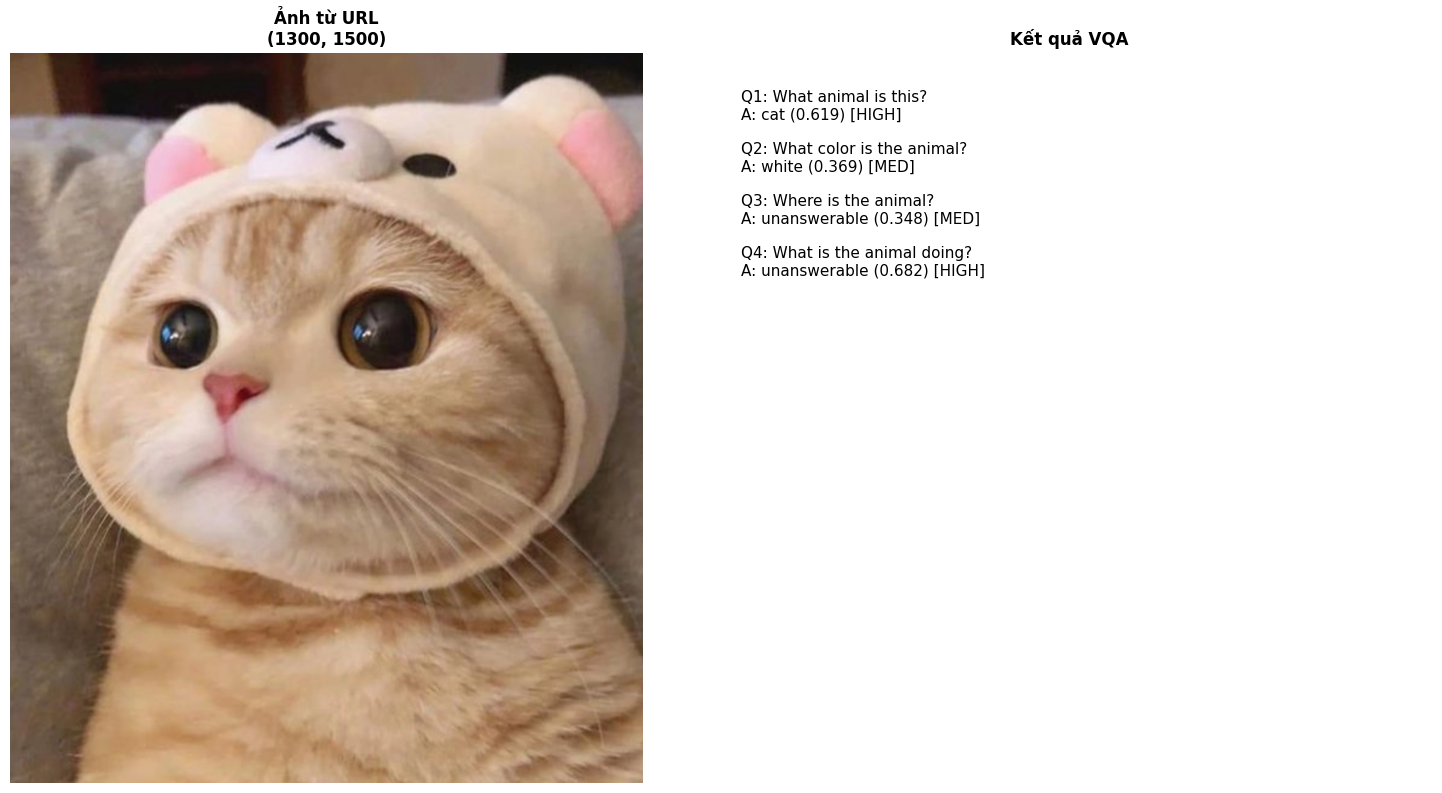

Hoàn thành!


In [67]:
# Test với URL và câu hỏi tùy chỉnh
# Thay đổi các giá trị bên dưới để test
# custom_url = "https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=500"  # Thay URL ở đây
custom_url = "https://cdn.mobilecity.vn/mobilecity-vn/images/2024/11/top-meme-meo-cuc-dang-yeu-74.png.webp" 
custom_questions = [
    "What animal is this?",          # Thay câu hỏi ở đây
    "What color is the animal?",
    "Where is the animal?",
    "What is the animal doing?"
]

print("CUSTOM VQA TEST")
print("=" * 50)

# Thực hiện VQA với custom input
custom_results = vqa_from_url(
    image_url=custom_url,
    questions=custom_questions,
    model=model,
    dataset=temp_dataset,
    device=device,
    feature_extractor=feature_extractor
)

# Hiển thị kết quả
if custom_results:
    print(f"\n{'KẾT QUẢ':=^50}")
    for pred in custom_results['predictions']:
        print(f"Q: {pred['question']}")
        print(f"A: {pred['answer']} ({pred['confidence']:.3f})")
        print()
    
    visualize_results(custom_results)
    
    print("Hoàn thành!")
else:
    print("Lỗi trong quá trình xử lý!")